In [264]:
import subprocess
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import scipy.optimize as so
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from math import sqrt
import subprocess
from scipy.optimize import curve_fit
sns.set()
sns.set_context('paper', font_scale=1.2)
from scipy.optimize import nnls#######################################################################################################################################################################################################
#######################################################################################################################################################################################################
# Path: Newsimulation.ipynb
#######################################################################################################################################################################################################
#######################################################################################################################################################################################################

# Parse EnergyPlus datetime string
energyplus_install_dir=r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\EnergyPlusV9-6-0"
output_relative_directory =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change"
idf_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\backup_august_8_23_original_workingfortraining\SmallOffice.idf"



#### SkyTEMPERATURE CHANGE
#idf_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\backup_august_8_23_original_workingfortraining\skytemperaturechange\SmallOffice.idf"




#epw_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\USA_GA_Atlanta-Fulton.County.AP-Brown.Field.722195_US.Normals.1991-2020.epw"
#epw_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\USA_WA_Bellingham.Intl.AP.727976_US.Normals.1981-2010.epw"
#epw_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\USA_FL_Tallahassee.Intl.AP.722140_TMY3.epw"

#epw_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\Final\validation\USA_FL_Tallahassee.Intl.AP.722140_US.Normals.1991-2020.epw"
epw_relative_filepath =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\validation\USA_NY_Albany.Intl.AP.725180_US.Normals.1991-2020.epw"
#USA_CO_Denver.Intl.AP.725650_US.Normals.1991-2020.epw

#mychange - idf_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\AirflowNetwork_MultiZone_SmallOffice_VAV111.idf"
#USA_CA_San.Francisco.Intl.AP.724940_TMY3
#USA_CO_Golden-NREL.724666_TMY3
def run_command(cmd_string, capture_output=False):
    # sourcery skip: raise-specific-error
    result = subprocess.run(cmd_string, capture_output=capture_output)
    if result.returncode != 0:
        raise Exception(f'Command failed with return code: {result.returncode}')
    print('---RETURNCODE---\n', result.returncode, '(SUCCESS)')
    return result



# building command string
cl_st=(f'"{energyplus_install_dir}\\energyplus" '
       + '--readvars '
       + f'--output-directory "{output_relative_directory}" '
       + f'--weather "{epw_relative_filepath}" '
       + f'"{idf_relative_filepath}"'
      )


# running the simulation
run_command(cl_st)

---RETURNCODE---
 0 (SUCCESS)


CompletedProcess(args='"D:\\PhD_Academics\\Buildings\\Tharaka\\Tharaka\\EnergyPlusV9-6-0\\energyplus" --readvars --output-directory "D:\\PhD_Academics\\Buildings\\Tharaka\\Tharaka\\meeting\\james\\week4_solar_and_new_cost_function\\DOF_change" --weather "D:\\PhD_Academics\\Buildings\\Tharaka\\Tharaka\\meeting\\james\\week4_solar_and_new_cost_function\\validation\\USA_NY_Albany.Intl.AP.725180_US.Normals.1991-2020.epw" "D:\\PhD_Academics\\Buildings\\Tharaka\\Tharaka\\meeting\\james\\week4_solar_and_new_cost_function\\backup_august_8_23_original_workingfortraining\\SmallOffice.idf"', returncode=0)

In [266]:
print("\n📌 Surface radiation columns found:")
for col in df.columns:
    if "Incident Solar Radiation" in col:
        print("  -", col)



📌 Surface radiation columns found:


In [267]:
# function to parse EnergyPlus datetime string
def parse_energyplus_datetime_string(st, year=2021):
    st = st.strip()
    month, day = map(int, [st[:2], st[3:5]])
    hour = int(st[7:9]) if st[7:9] != '24' else 0
    minute = int(st[10:12])
    dt = pd.Timestamp(year, month, day, hour, minute)
    return dt if st[7:9] != '24' else dt + pd.Timedelta('1 day')

In [268]:
df=pd.read_csv(r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\eplusout.csv",
               parse_dates=[0],
               index_col=[0],
               date_parser=parse_energyplus_datetime_string
              )

df_sim = pd.read_csv(r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\eplusout.csv")

C:\Users\USER\AppData\Local\Temp\ipykernel_24200\3946068532.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df=pd.read_csv(r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\eplusout.csv",


In [269]:
rename_dict = {
    "NORTH ZONE:Zone Air Temperature [C](TimeStep)": "North_Zone_Air_Temperature", 
    "WEST ZONE:Zone Air Temperature [C](TimeStep)": "West_Zone_Air_Temperature", 
    "EAST ZONE:Zone Air Temperature [C](TimeStep)": "East_Zone_Air_Temperature", 
    "Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep)": "Ambient_Temperature", 
    "MAIN HEATING COIL 1:Heating Coil Heating Rate [W](TimeStep)": "Heating_Power", 
    "ZONE3TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z1",
    "ZONE1TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z2",
    "ZONE2TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z3",
    "NORTH ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "North_Zone_Solar_Rate",
    "NORTH ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "North_Zone_Solar_Energy",
    "WEST ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "West_Zone_Solar_Rate",
    "WEST ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "West_Zone_Solar_Energy",
    "EAST ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "East_Zone_Solar_Rate",
    "EAST ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "East_Zone_Solar_Energy",
    "Date/Time": "Time"
}
df.rename(columns=rename_dict, inplace=True)
time_steps = np.arange(len(df))
df['time_steps'] = time_steps

📈 Max solar rate (North Zone): 145.8920316105107


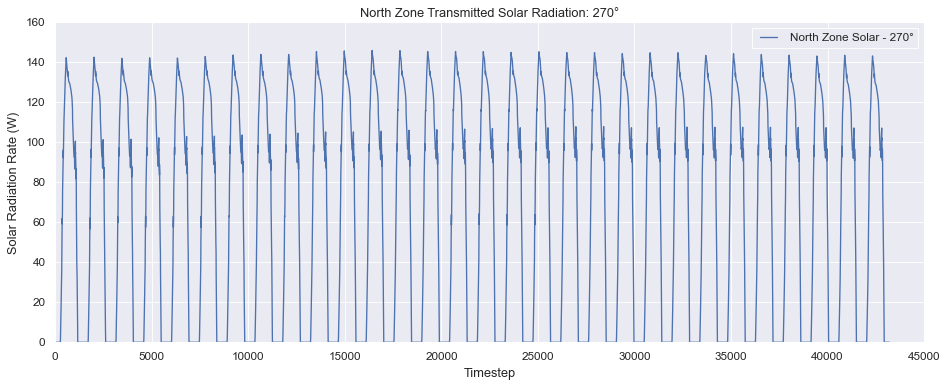

In [270]:
df['time_steps'] = range(len(df))
rotation_label = "270°"
# 🔎 Preview to confirm
print("📈 Max solar rate (North Zone):", df["North_Zone_Solar_Rate"].max())

# 📊 Plot
plt.figure(figsize=(12, 5))
plt.plot(df['time_steps'], df['North_Zone_Solar_Rate'], label=f'North Zone Solar - {rotation_label}')
plt.title(f"North Zone Transmitted Solar Radiation: {rotation_label}")
plt.xlabel("Timestep")
plt.ylabel("Solar Radiation Rate (W)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [272]:
minutes_to_plot = 2592000  # Define the number of minutes to plot

# Ensure that we have enough data to plot 200 minutes
if len(df) > minutes_to_plot:
    plot_data = df.iloc[:minutes_to_plot]
else:
    plot_data = df  # Not enough data, use what we have

# create and modify Heating Input column
df['Heating Input'] = df['Heating_Power'].apply(lambda x: 1 if x > 0 else 0).astype(int)
df['Heating_Input_Z1'] = df['Heating_Power_Z1'].apply(lambda x: 1 if x > 0 else 0).astype(int)
df['Heating_Input_Z2'] = df['Heating_Power_Z2'].apply(lambda x: 1 if x > 0 else 0).astype(int)
df['Heating_Input_Z3'] = df['Heating_Power_Z3'].apply(lambda x: 1 if x > 0 else 0).astype(int)

# Format the current date and time
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')


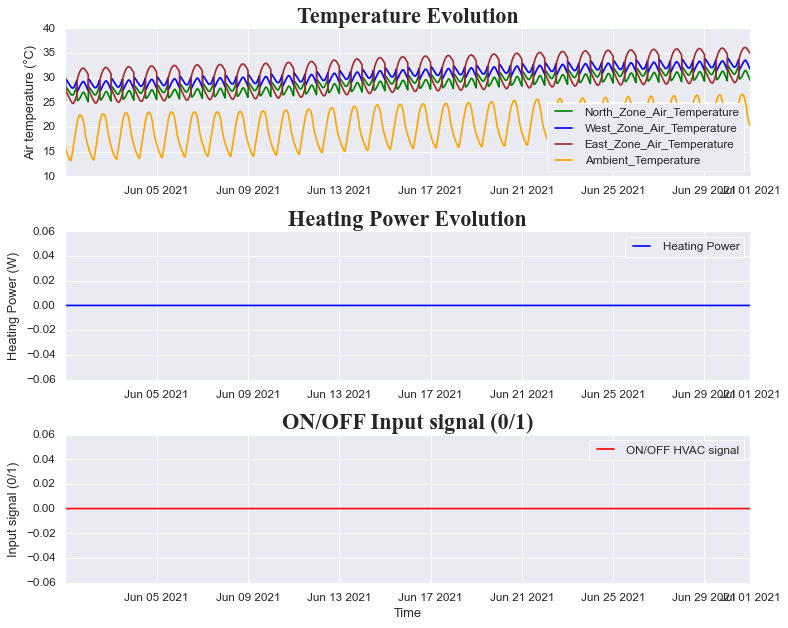

In [273]:
# Specify the path and filename and save the DataFrame to a new CSV file
file_path =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change"
filename = f"{file_path}imulation_results_{timestamp}.csv"
filename2 = r'D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\Indoor_Temperatures2.csv'
# Specify the file path

df.to_csv(filename, index=False)
df.to_csv(filename2, index=False)


fig, axs = plt.subplots(3, 1, figsize=(10, 8), tight_layout=True)
minutes_to_plot = 2592000   # Define the number of minutes to plot

# Ensure that we have enough data to plot 200 minutes
if len(df) > minutes_to_plot:
    plot_data = df.iloc[:minutes_to_plot]
else:
    plot_data = df  # Not enough data, use what we have

# Plot T_int1, T_int2, T_int3, T_ext
for temp, color in zip(['North_Zone_Air_Temperature', 'West_Zone_Air_Temperature', 'East_Zone_Air_Temperature', 'Ambient_Temperature'], ['green', 'blue', 'brown', 'orange']):
    axs[0].plot(plot_data.index, plot_data[temp], color=color, linewidth=1.5, label=temp)
axs[0].set(ylabel='Temperature (°C)')
axs[0].legend(loc='best')
axs[0].set_ylabel('Air temperature (°C)')
axs[0].set_title('Temperature Evolution', fontname="Times New Roman", size=20, fontweight="bold")

# Plot P_hea1
axs[1].plot(plot_data.index, plot_data['Heating_Power'], color='blue', linewidth=1.5, label='Heating Power')
axs[1].set(ylabel='Heating Power (W)')
axs[1].legend(loc='best')
axs[1].set_ylabel('Heating Power (W)')
axs[1].set_title('Heating Power Evolution', fontname="Times New Roman", size=20, fontweight="bold")

# Plot P_hea2
axs[2].plot(plot_data.index, plot_data['Heating Input'], color='red', linewidth=1.5, label='ON/OFF HVAC signal')
axs[2].set(xlabel='Time', ylabel='P_hea2')
axs[2].legend(loc='best')
axs[2].set_ylabel('Input signal (0/1)')
axs[2].set_title('ON/OFF Input signal (0/1)', fontname="Times New Roman", size=20, fontweight="bold")



plt.show()

plt.show()




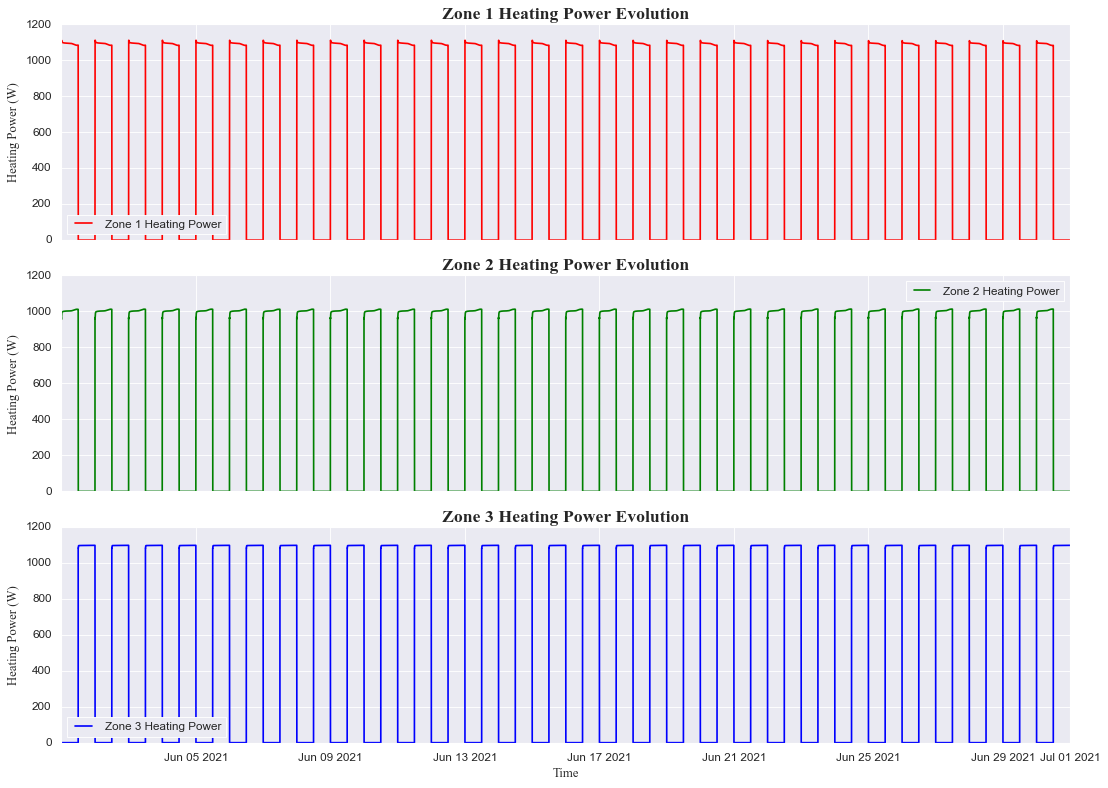

In [274]:
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
# Plot for Zone 1
axs[0].plot(df.index, df['Heating_Power_Z1'], color='red', linewidth=1.5, label='Zone 1 Heating Power')
axs[0].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[0].legend(loc='best')
axs[0].set_title('Zone 1 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")

# Plot for Zone 2
axs[1].plot(df.index, df['Heating_Power_Z2'], color='green', linewidth=1.5, label='Zone 2 Heating Power')
axs[1].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[1].legend(loc='best')
axs[1].set_title('Zone 2 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")

# Plot for Zone 3
axs[2].plot(df.index, df['Heating_Power_Z3'], color='blue', linewidth=1.5, label='Zone 3 Heating Power')
axs[2].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[2].set_xlabel('Time', fontname="Times New Roman")
axs[2].legend(loc='best')
axs[2].set_title('Zone 3 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")

plt.tight_layout()
plt.show()

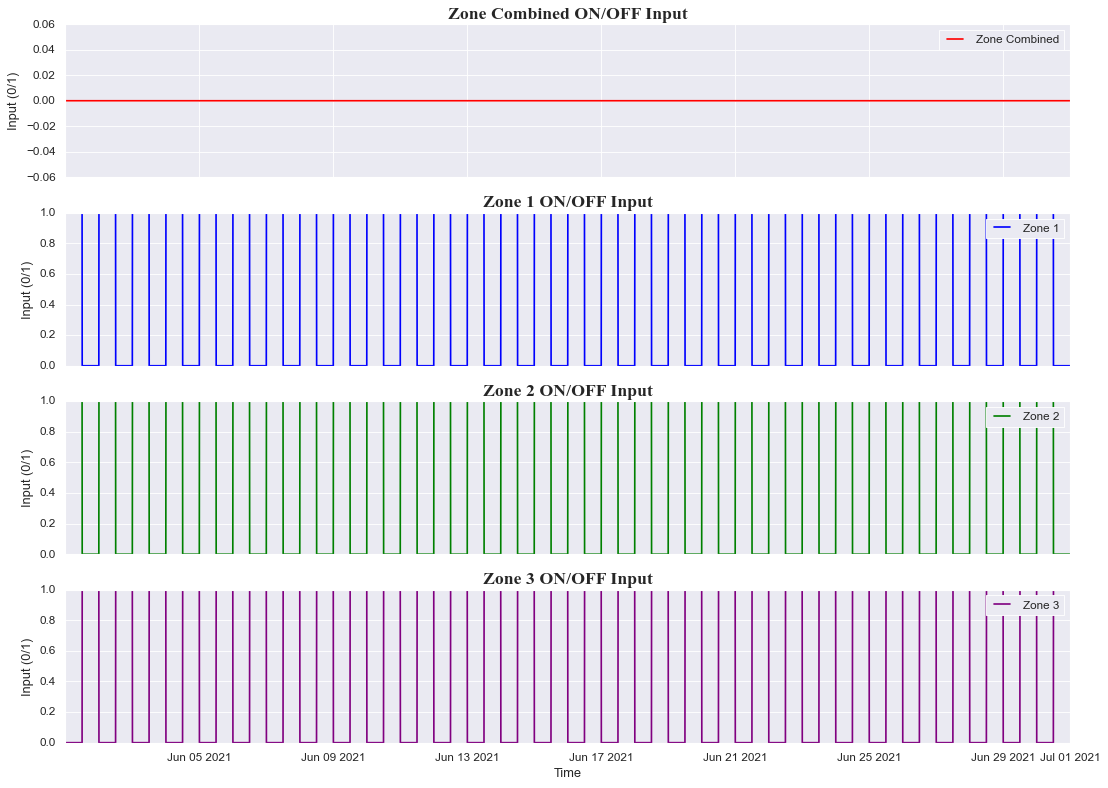

In [275]:
import matplotlib.pyplot as plt

# Create subplots for Heating Input signals
fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# Plot for overall Heating Input
axs[0].plot(df.index, df['Heating Input'], color='red', linewidth=1.5, label='Zone Combined')
axs[0].set_ylabel('Input (0/1)')
axs[0].set_title('Zone Combined ON/OFF Input', fontname="Times New Roman", size=16, fontweight="bold")
axs[0].legend(loc='upper right')

# Plot for Zone 1
axs[1].plot(df.index, df['Heating_Input_Z1'], color='blue', linewidth=1.5, label='Zone 1')
axs[1].set_ylabel('Input (0/1)')
axs[1].set_title('Zone 1 ON/OFF Input', fontname="Times New Roman", size=16, fontweight="bold")
axs[1].legend(loc='upper right')

# Plot for Zone 2
axs[2].plot(df.index, df['Heating_Input_Z2'], color='green', linewidth=1.5, label='Zone 2')
axs[2].set_ylabel('Input (0/1)')
axs[2].set_title('Zone 2 ON/OFF Input', fontname="Times New Roman", size=16, fontweight="bold")
axs[2].legend(loc='upper right')

# Plot for Zone 3
axs[3].plot(df.index, df['Heating_Input_Z3'], color='purple', linewidth=1.5, label='Zone 3')
axs[3].set_ylabel('Input (0/1)')
axs[3].set_xlabel('Time')
axs[3].set_title('Zone 3 ON/OFF Input', fontname="Times New Roman", size=16, fontweight="bold")
axs[3].legend(loc='upper right')

plt.tight_layout()
plt.show()


In [138]:
import matplotlib.pyplot as plt

# Make sure index is datetime
df.index = pd.to_datetime(df.index)

# Select 1 day (adjust date as needed)
one_day = df.loc['2021-5-05']

# Plot
fig, axs = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Zone 1
axs[0].plot(one_day.index, one_day['Heating_Power_Z1'], color='red', linewidth=1.5, label='Zone 1 Heating Power')
axs[0].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[0].legend(loc='upper right')
axs[0].set_title('Zone 1 Heating Power ', fontname="Times New Roman", fontsize=14, fontweight="bold")

# Zone 2
axs[1].plot(one_day.index, one_day['Heating_Power_Z2'], color='green', linewidth=1.5, label='Zone 2 Heating Power')
axs[1].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[1].legend(loc='upper right')
axs[1].set_title('Zone 2 Heating Power', fontname="Times New Roman", fontsize=14, fontweight="bold")

# Zone 3
axs[2].plot(one_day.index, one_day['Heating_Power_Z3'], color='blue', linewidth=1.5, label='Zone 3 Heating Power')
axs[2].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[2].set_xlabel('Time', fontname="Times New Roman")
axs[2].legend(loc='upper right')
axs[2].set_title('Zone 3 Heating Power', fontname="Times New Roman", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()


KeyError: '2021-5-05'

In [276]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates

# --- "MATLAB-like" look (white bg) ---
plt.style.use('classic')
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor']   = 'white'
mpl.rcParams['savefig.facecolor']= 'white'
mpl.rcParams['font.family']      = 'Times New Roman'
mpl.rcParams['axes.grid']        = False  # set True if you want grid lines

# Ensure datetime index
df.index = pd.to_datetime(df.index)

# Use the same day as before
day_str = '2021-05-05'
one_day = df.loc[day_str]

# Build figure
fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# Helper for consistent ON/OFF axes
def format_onoff(ax):
    ax.set_ylabel('Input (0/1)')
    ax.set_ylim(-0.1, 1.1)
    ax.set_yticks([0, 1])

# Zone Combined
axs[0].plot(one_day.index, one_day['Heating Input'], linewidth=1.5,
            drawstyle='steps-post', label='Zone Combined')
axs[0].set_title('Zone Combined ON/OFF Input', fontsize=16, fontweight='bold')
axs[0].legend(loc='upper right', frameon=False)
format_onoff(axs[0])

# Zone 1
axs[1].plot(one_day.index, one_day['Heating_Input_Z1'], linewidth=1.5,
            drawstyle='steps-post', label='Zone 1')
axs[1].set_title('Zone 1 ON/OFF Input', fontsize=16, fontweight='bold')
axs[1].legend(loc='upper right', frameon=False)
format_onoff(axs[1])

# Zone 2
axs[2].plot(one_day.index, one_day['Heating_Input_Z2'], linewidth=1.5,
            drawstyle='steps-post', label='Zone 2')
axs[2].set_title('Zone 2 ON/OFF Input', fontsize=16, fontweight='bold')
axs[2].legend(loc='upper right', frameon=False)
format_onoff(axs[2])

# Zone 3
axs[3].plot(one_day.index, one_day['Heating_Input_Z3'], linewidth=1.5,
            drawstyle='steps-post', label='Zone 3')
axs[3].set_title('Zone 3 ON/OFF Input', fontsize=16, fontweight='bold')
axs[3].legend(loc='upper right', frameon=False)
format_onoff(axs[3])
axs[3].set_xlabel('Time')

# Nice time formatting on x-axis
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

# Optional: save with white background at high DPI
fig.savefig('heating_inputs_one_day_matlab_like.png', dpi=200, bbox_inches='tight')


KeyError: '2021-05-05'

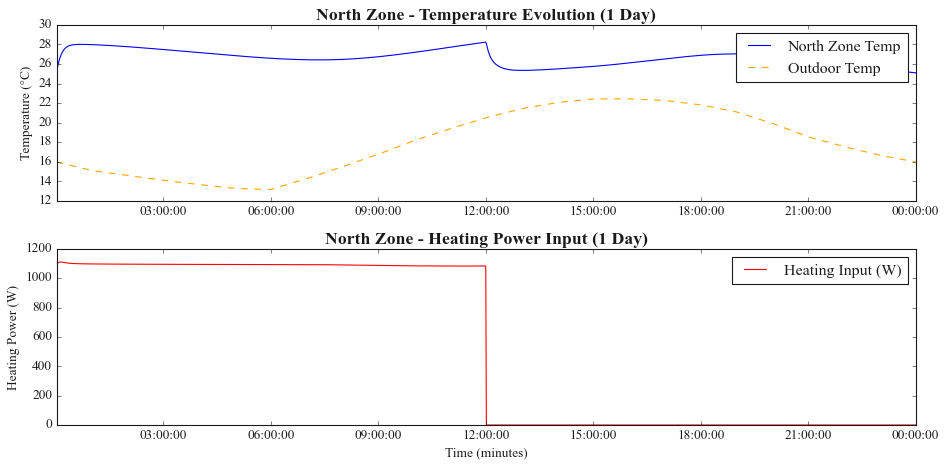

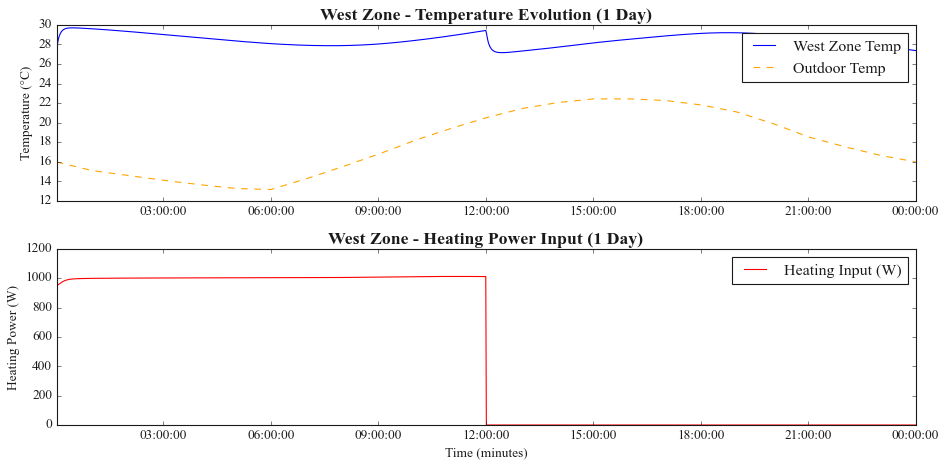

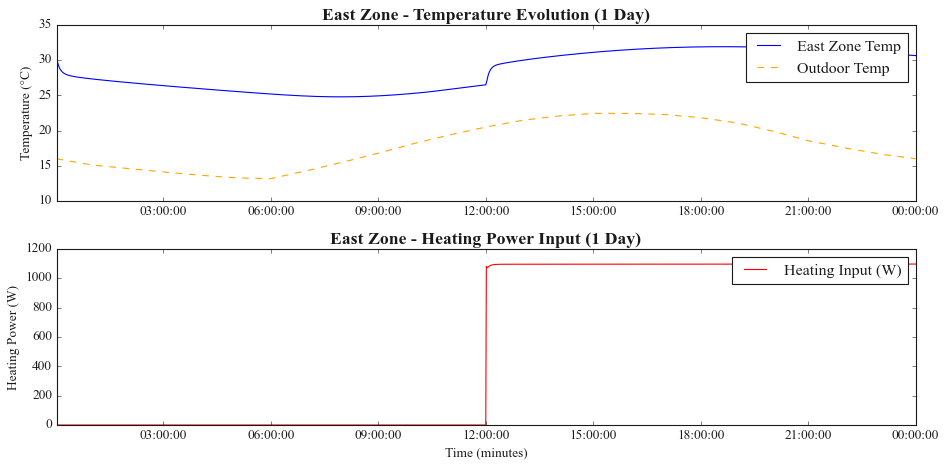

In [278]:
import matplotlib.pyplot as plt

# Define how many minutes = 1 day
minutes_in_one_day = 1440  

# Ensure data is long enough
if len(df) >= minutes_in_one_day:
    day_data = df.iloc[:minutes_in_one_day]
else:
    day_data = df  # Use what we have

zones = [
    ('North_Zone_Air_Temperature', 'Heating_Power_Z1', 'North Zone'),
    ('West_Zone_Air_Temperature', 'Heating_Power_Z2', 'West Zone'),
    ('East_Zone_Air_Temperature', 'Heating_Power_Z3', 'East Zone'),
]

for temp_col, power_col, zone_name in zones:
    fig, axs = plt.subplots(2, 1, figsize=(12, 6), tight_layout=True)

    # Temperature subplot
    axs[0].plot(day_data.index, day_data[temp_col], label=f'{zone_name} Temp', color='blue')
    axs[0].plot(day_data.index, day_data['Ambient_Temperature'], label='Outdoor Temp', color='orange', linestyle='--')
    axs[0].set_ylabel('Temperature (°C)')
    axs[0].set_title(f'{zone_name} - Temperature Evolution (1 Day)', fontname="Times New Roman", fontsize=16, fontweight='bold')
    axs[0].legend()

    # Heating power input subplot
    axs[1].plot(day_data.index, day_data[power_col], label='Heating Input (W)', color='red')
    axs[1].set_ylabel('Heating Power (W)')
    axs[1].set_xlabel('Time (minutes)')
    axs[1].set_title(f'{zone_name} - Heating Power Input (1 Day)', fontname="Times New Roman", fontsize=16, fontweight='bold')
    axs[1].legend()

    plt.show()


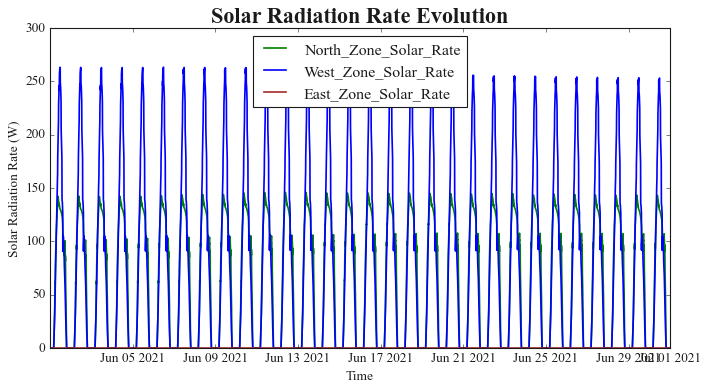

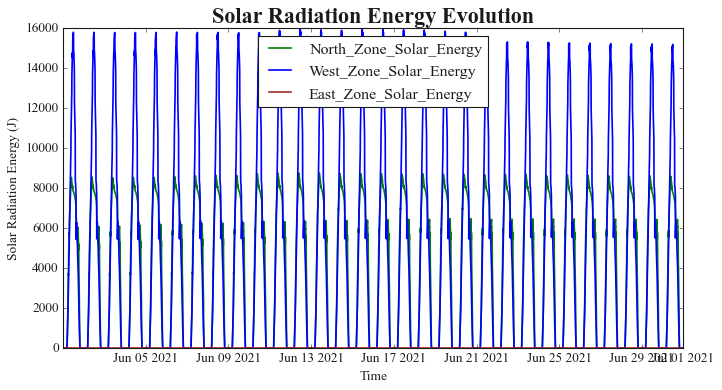

In [279]:
import matplotlib.pyplot as plt

# Plot Solar Radiation Rate
plt.figure(figsize=(10, 5))
for zone, color in zip(['North_Zone_Solar_Rate', 'West_Zone_Solar_Rate', 'East_Zone_Solar_Rate'], ['green', 'blue', 'brown']):
    plt.plot(plot_data.index, plot_data[zone], color=color, linewidth=1.5, label=zone)
plt.ylabel('Solar Radiation Rate (W)')
plt.xlabel('Time')
plt.legend(loc='best')
plt.title('Solar Radiation Rate Evolution', fontname="Times New Roman", size=20, fontweight="bold")
plt.show()

# Plot Solar Radiation Energy
plt.figure(figsize=(10, 5))
for zone, color in zip(['North_Zone_Solar_Energy', 'West_Zone_Solar_Energy', 'East_Zone_Solar_Energy'], ['green', 'blue', 'brown']):
    plt.plot(plot_data.index, plot_data[zone], color=color, linewidth=1.5, label=zone)
plt.ylabel('Solar Radiation Energy (J)')
plt.xlabel('Time')
plt.legend(loc='best')
plt.title('Solar Radiation Energy Evolution', fontname="Times New Roman", size=20, fontweight="bold")
plt.show()

[4.44629785e+03 1.73631372e+03 3.94476443e+03 2.67577090e+02
 1.15655002e+02 1.95086420e+02 3.07613996e+00 4.95735065e+01
 1.87237549e-14 8.34593481e-03]
D1: 1.8723754931378877e-14
D2: 0.008345934811713711
     K12    K23    K10      K20   K30      C1      C2      C3   D1   D2
0  267.6  195.1  115.7  3.07614  49.6  4446.3  1736.3  3944.8  0.0  0.0
RMSE for Zone 1: 0.57
RMSE for Zone 2: 0.12
RMSE for Zone 3: 0.49


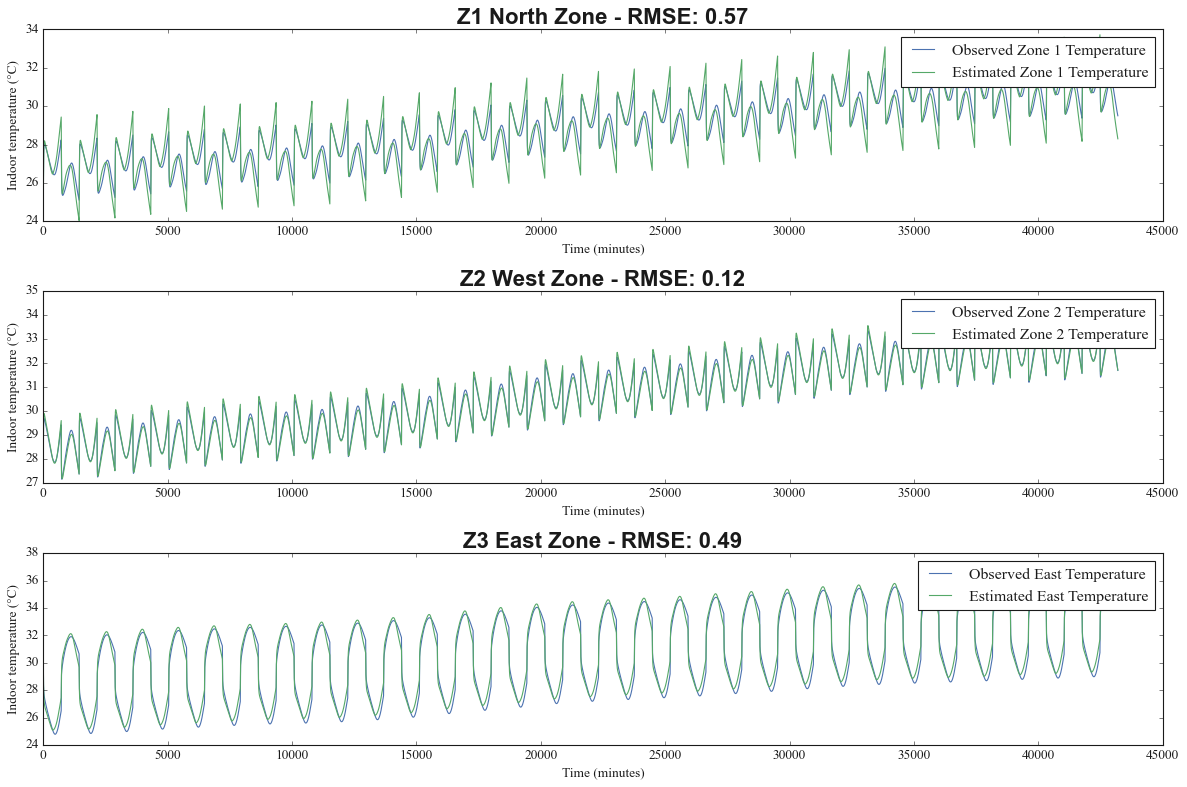

In [285]:
############################################### NEW SOLAR BUT OLD MODEL AGAIN
from scipy.optimize import lsq_linear
#filename = r"C:\...\Resultssimulation_results_2024-06-08_02-07-16.csv"
df = pd.read_csv(filename)

time = df['time_steps'].values
num_steps = len(time)
dt = 1

# Extract data
T_outdoor = df['Ambient_Temperature'].values
zone1 = df['North_Zone_Air_Temperature'].values  
zone2 = df['West_Zone_Air_Temperature'].values 
zone3 = df['East_Zone_Air_Temperature'].values 
U1 = df['Heating_Power_Z1'].values
U2 = df['Heating_Power_Z2'].values
U3 = df['Heating_Power_Z3'].values
NS1 = df['North_Zone_Solar_Rate'].values
WS2 = df['West_Zone_Solar_Rate'].values
ES3 = df['East_Zone_Solar_Rate'].values
dt=1



# Compute temperature derivatives
dT1_dt = np.gradient(zone1, dt)
dT2_dt = np.gradient(zone2, dt)
dT3_dt = np.gradient(zone3, dt)

# Update number of parameters: C1, C2, C3, K12, K10, K23, K20, K30, D1, D2
num_params = 10
A = np.zeros((3 * num_steps, num_params))
b = np.zeros(3 * num_steps)
'''
# Fill matrices
for i in range(num_steps):
    A[3*i] = [
        dT1_dt[i], 0, 0,
        -(zone2[i] - zone1[i]),  # K12
        0,                       # K23 (skip)
        -(T_outdoor[i] - zone1[i]),  # K10
        0, 0,                    # K20, K30
        NS1[i], 0                # D1, D2
    ]
    
    A[3*i + 1] = [
        0, dT2_dt[i], 0,
        -(zone1[i] - zone2[i]),  # K12
        -(zone3[i] - zone2[i]),  # K23
        0,                       # K10
        -(T_outdoor[i] - zone2[i]),  # K20
        0,
        0, WS2[i]                # D1, D2
    ]
    
    A[3*i + 2] = [
        0, 0, dT3_dt[i],
        0,
        -(zone2[i] - zone3[i]),  # K23
        0, 0,
        -(T_outdoor[i] - zone3[i]),  # K30
        0, 0
    ]

    # ✅ Add this
    b[3*i]     = U1[i]
    b[3*i + 1] = U2[i]
    b[3*i + 2] = U3[i]



lower_bounds = np.zeros(10)
lower_bounds[8] = 0.1  # D1
lower_bounds[9] = 0.1 # D2
upper_bounds = np.full(10, np.inf)  # No upper bound

# Solve
from scipy.optimize import nnls
res = lsq_linear(A, b, bounds=(lower_bounds, upper_bounds), method='trf')
theta = res.x
#theta, rnorm = nnls(A, b)
C1, C2, C3, K12, K23, K10, K20, K30, D1, D2 = theta
'''

for i in range(num_steps):
    # Zone 1
    A[3*i] = [
        dT1_dt[i], 0, 0,
        -(zone2[i] - zone1[i]),   # K12
        -(T_outdoor[i] - zone1[i]),  # K10
        0, 0, 0,
        -NS1[i], 0  # D1
    ]
    b[3*i] = U1[i]

    # Zone 2
    A[3*i + 1] = [
        0, dT2_dt[i], 0,
        -(zone1[i] - zone2[i]),   # K12
        0,
        -(zone3[i] - zone2[i]),   # K23
        -(T_outdoor[i] - zone2[i]),  # K20
        0,
        0, -WS2[i]  # D2
    ]
    b[3*i + 1] = U2[i]

    # Zone 3
    A[3*i + 2] = [
        0, 0, dT3_dt[i],
        0,
        0,
        -(zone2[i] - zone3[i]),  # K23
        0,
        -(T_outdoor[i] - zone3[i]),  # K30
        0, 0
    ]
    b[3*i + 2] = U3[i]

# Solve NNLS
# Order:       [C1,    C2,    C3,    K12,   K10,   K23,   K20,   K30,   D1,   D2]
lower_bounds = [0,   0,   0,   0,   0,   0,   0.1,   0,   0.0,  0.0]  # example: D1/D2 ≥ 0.5
#upper_bounds = [np.inf]*10  # or specify [10000, ..., 2.0, 2.0] if you want to cap D1/D2 at 2.0
upper_bounds = [
    10000.0,  # C1
    10000.0,  # C2
    10000.0,  # C3
    1000.0,   # K12
    1000.0,   # K10
    1000.0,   # K23
    1000.0,   # K20
    1000.0,   # K30
    5.0,      # D1
    5.0       # D2
]

res = lsq_linear(A, b, bounds=(lower_bounds, upper_bounds), method='trf')
theta = res.x




#theta, rnorm = nnls(A, b)
C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = theta
theta
print(theta)

# Print the identified parameters

print(f"D1: {D1}")
print(f"D2: {D2}")
#print(f"D3: {D3}")


# Round each value to one decimal place
data_dict = {
    'K12': round(K12, 1), 
    'K23': round(K23, 1), 
    'K10': round(K10, 1), 
    'K20': round(K20, 5), 
    'K30': round(K30, 1), 
    'C1': round(C1, 1), 
    'C2': round(C2, 1), 
    'C3': round(C3, 1),
    'D1': round(D1, 1),
    'D2': round(D2, 1),
 #   'D3': round(D3, 1)
}

# Convert the dictionary to a DataFrame
df = pd.DataFrame([data_dict])
print(df)
# Specify the file path
#Rc_Parameters = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week3_parameter_freezing\DOF_change\Parameter_Estimates.csv"

# Check if file exists and is not empty
#if os.path.isfile(Rc_Parameters) and os.path.getsize(Rc_Parameters) > 0:
    # If file exists and is not empty, do not write header
 #   df.to_csv(Rc_Parameters, mode='a', header=False, index=False)
#else:
    # If file doesn't exist or is empty, write header
#    df.to_csv(Rc_Parameters, mode='w', header=True, index=False)
    
#K12=K12+1000  
###############################################################################################################################    
D3=0 #just for measuring
######################################################################################################################    
# Calculate the estimated temperatures
estimated_zone1 = np.zeros(num_steps)
estimated_zone2 = np.zeros(num_steps)
estimated_zone3 = np.zeros(num_steps)

estimated_zone1[0] = zone1[0]  # Initial temperature for zone1
estimated_zone2[0] = zone2[0]  # Initial temperature for zone2
estimated_zone3[0] = zone3[0]  # Initial temperature for zone3

for i in range(1, num_steps):
    estimated_zone1[i] = estimated_zone1[i-1] + (K12*(zone2[i-1] - estimated_zone1[i-1]) + K10*(T_outdoor[i-1] - estimated_zone1[i-1]) + U1[i-1] + D1*NS1[i-1] )/C1 * dt 
    estimated_zone2[i] = estimated_zone2[i-1] + (K12*(zone1[i-1] - estimated_zone2[i-1]) + K23*(zone3[i-1] - estimated_zone2[i-1]) + K20*(T_outdoor[i-1] - estimated_zone2[i-1]) + U2[i-1] + D2*WS2[i-1] )/C2 * dt 
    estimated_zone3[i] = estimated_zone3[i-1] + (K23*(zone2[i-1] - estimated_zone3[i-1]) + K30*(T_outdoor[i-1] - estimated_zone3[i-1]) + U3[i-1]  + D3 * ES3[i-1])/C3 * dt 
    
    
rmse_y1 = np.sqrt(mean_squared_error(zone1, estimated_zone1))
rmse_y2 = np.sqrt(mean_squared_error(zone2, estimated_zone2))
rmse_y3 = np.sqrt(mean_squared_error(zone3, estimated_zone3))


print(f"RMSE for Zone 1: {rmse_y1:.2f}")
print(f"RMSE for Zone 2: {rmse_y2:.2f}")
print(f"RMSE for Zone 3: {rmse_y3:.2f}")


# Round each value to one decimal place
RMSE = {
    'RMSE Zone 1': rmse_y1, 
    'RMSE Zone 2': rmse_y2, 
    'RMSE Zone 3': rmse_y3
}

df = pd.DataFrame([RMSE])

# Specify the file path
#RMSE = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week3_parameter_freezing\DOF_change\RMSE.csv"





###########################################################################################################################################################################################################################
# Assuming `time` is an array or series that increments per minute, we trim all arrays to some number of minutes
minutes_to_plot = 2592000
if len(time) > minutes_to_plot:
    plot_time = time[:minutes_to_plot]
    plot_zone1 = zone1[:minutes_to_plot]
    plot_estimated_zone1 = estimated_zone1[:minutes_to_plot]
    plot_zone2 = zone2[:minutes_to_plot]
    plot_estimated_zone2 = estimated_zone2[:minutes_to_plot]
    plot_zone3 = zone3[:minutes_to_plot]
    plot_estimated_zone3 = estimated_zone3[:minutes_to_plot]
else:
    # Not enough data, use what we have
    plot_time = time
    plot_zone1 = zone1
    plot_estimated_zone1 = estimated_zone1
    plot_zone2 = zone2
    plot_estimated_zone2 = estimated_zone2
    plot_zone3 = zone3
    plot_estimated_zone3 = estimated_zone3
    
    
    
###########################################################################################################################################################################################################################    

# Create a DataFrame and save the verification data to a CSV file
data = {
    'Time': plot_time,
    'Observed_Temperature_Zone_1': plot_zone1,
    'Estimated_Temperature_Zone_1': plot_estimated_zone1,
    'Observed_Temperature_Zone_2': plot_zone2,
    'Estimated_Temperature_Zone_2': plot_estimated_zone2,
    'Observed_Temperature_Zone_3': plot_zone3,
    'Estimated_Temperature_Zone_3': plot_estimated_zone3,
    'Outdoor_Tmperature': T_outdoor
}
#df = pd.DataFrame(data)
# Save to CSV
#print(f"Verification Data Total Points: {len(plot_time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {plot_time[-1]}")

#df.to_csv('D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting/james/week3_parameter_freezing/DOF_change/verification.csv', index=False)



##########################################################################################################################################################################################################################

#Plotting the results
plt.figure(figsize=(15, 10))
#plot_time=df
# North Zone
plt.subplot(3, 1, 1)
plt.plot(plot_time, plot_zone1, label='Observed Zone 1 Temperature')
plt.plot(plot_time, plot_estimated_zone1, label='Estimated Zone 1 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"Z1 North Zone - RMSE: {rmse_y1:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# West Zone
plt.subplot(3, 1, 2)
plt.plot(plot_time, plot_zone2, label='Observed Zone 2 Temperature')
plt.plot(plot_time, plot_estimated_zone2, label='Estimated Zone 2 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"Z2 West Zone - RMSE: {rmse_y2:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# East Zone
plt.subplot(3, 1, 3)
plt.plot(plot_time, plot_zone3, label='Observed East Temperature')
plt.plot(plot_time, plot_estimated_zone3, label='Estimated East Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"Z3 East Zone - RMSE: {rmse_y3:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

plt.tight_layout()
plt.show()
#print(f"Total data points available: {len(time)}")#
#print(f"First time value: {time[0]}, Last time value: {time[-1]}")


In [288]:
import pandas as pd
import os

# =========================================================
# Input and output files
# =========================================================
input_csv = filename   # uses the same input file variable from your code
output_csv = "used_columns_export.csv"

# =========================================================
# Read original file
# =========================================================
df = pd.read_csv(input_csv)

# =========================================================
# Detect a usual date/time column if present
# =========================================================
datetime_col = None
possible_time_cols = [
    "Date/Time", "Date_Time", "datetime", "Datetime", "date_time",
    "Timestamp", "timestamp", "Time", "time", "time_steps"
]

for col in possible_time_cols:
    if col in df.columns:
        datetime_col = col
        break

# =========================================================
# Required columns used in your model
# =========================================================
required_cols = [
    "Ambient_Temperature",
    "North_Zone_Air_Temperature",
    "West_Zone_Air_Temperature",
    "East_Zone_Air_Temperature",
    "Heating_Power_Z1",
    "Heating_Power_Z2",
    "Heating_Power_Z3",
    "North_Zone_Solar_Rate",
    "West_Zone_Solar_Rate",
    "East_Zone_Solar_Rate"
]

# Check missing columns
missing = [col for col in required_cols if col not in df.columns]
if missing:
    raise ValueError(f"These required columns are missing from the input file: {missing}")

# =========================================================
# Build export dataframe
# =========================================================
export_df = pd.DataFrame()

# Add time/date column
if datetime_col is not None:
    export_df["time_or_date"] = df[datetime_col]
    
    # Also try to create a parsed datetime column if possible
    try:
        export_df["parsed_datetime"] = pd.to_datetime(df[datetime_col], errors="coerce")
    except Exception:
        export_df["parsed_datetime"] = pd.NaT
else:
    # fallback if no time/date column exists
    export_df["time_or_date"] = range(len(df))
    export_df["parsed_datetime"] = pd.NaT

# Add all columns used in the code
export_df["Outdoor_Temperature"] = df["Ambient_Temperature"]
export_df["Zone1_Temperature"] = df["North_Zone_Air_Temperature"]
export_df["Zone2_Temperature"] = df["West_Zone_Air_Temperature"]
export_df["Zone3_Temperature"] = df["East_Zone_Air_Temperature"]

export_df["Zone1_Heating_Input"] = df["Heating_Power_Z1"]
export_df["Zone2_Heating_Input"] = df["Heating_Power_Z2"]
export_df["Zone3_Heating_Input"] = df["Heating_Power_Z3"]

export_df["Zone1_Solar"] = df["North_Zone_Solar_Rate"]
export_df["Zone2_Solar"] = df["West_Zone_Solar_Rate"]
export_df["Zone3_Solar"] = df["East_Zone_Solar_Rate"]

# =========================================================
# Save file
# =========================================================
export_df.to_csv(output_csv, index=False)

print(f"Created file: {os.path.abspath(output_csv)}")
print("Columns saved:")
print(export_df.columns.tolist())
print(export_df.head())

Created file: C:\Users\USER\used_columns_export.csv
Columns saved:
['time_or_date', 'parsed_datetime', 'Outdoor_Temperature', 'Zone1_Temperature', 'Zone2_Temperature', 'Zone3_Temperature', 'Zone1_Heating_Input', 'Zone2_Heating_Input', 'Zone3_Heating_Input', 'Zone1_Solar', 'Zone2_Solar', 'Zone3_Solar']
   time_or_date               parsed_datetime  Outdoor_Temperature  \
0             0 1970-01-01 00:00:00.000000000            15.985167   
1             1 1970-01-01 00:00:00.000000001            15.970333   
2             2 1970-01-01 00:00:00.000000002            15.955500   
3             3 1970-01-01 00:00:00.000000003            15.940667   
4             4 1970-01-01 00:00:00.000000004            15.925833   

   Zone1_Temperature  Zone2_Temperature  Zone3_Temperature  \
0          25.253597          27.580345          30.372167   
1          25.516509          27.912423          29.995397   
2          25.795536          28.245666          29.627041   
3          26.055219        

Estimated K10 = 82.1031
Estimated K20 = 44.9971
RMSE for Zone 1: 0.94
RMSE for Zone 2: 0.49
RMSE for Zone 3: 1.00


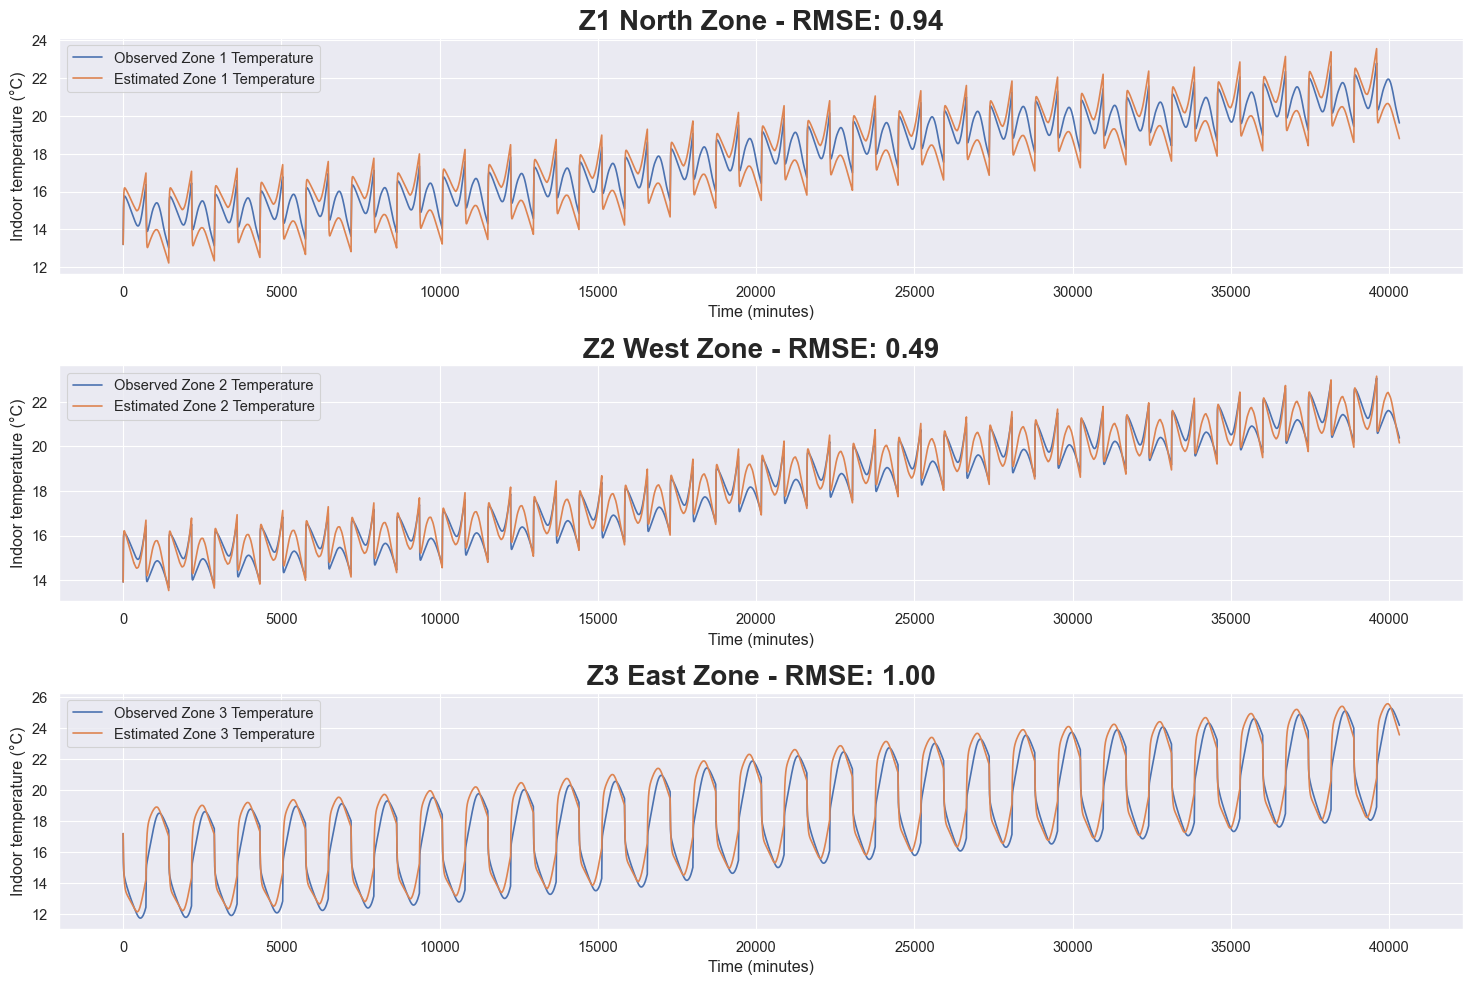

In [22]:

# =========================
# 1) Load your simulation CSV (same columns as in pasted.txt)
# =========================
#filename = "YOUR_SIMULATION_RESULTS.csv"   # <-- set this
#df = pd.read_csv(filename)
df = pd.read_csv(filename)


time = df['time_steps'].values
num_steps = len(time)
dt = 1  # minutes (as in your script)

T_outdoor = df['Ambient_Temperature'].values
zone1 = df['North_Zone_Air_Temperature'].values
zone2 = df['West_Zone_Air_Temperature'].values
zone3 = df['East_Zone_Air_Temperature'].values

U1 = df['Heating_Power_Z1'].values
U2 = df['Heating_Power_Z2'].values
U3 = df['Heating_Power_Z3'].values

NS1 = df['North_Zone_Solar_Rate'].values
WS2 = df['West_Zone_Solar_Rate'].values
ES3 = df['East_Zone_Solar_Rate'].values

# =========================
# 2) Freeze parameters (your provided values)
# =========================
K12 = 427.4
K23 = 163.0
K30 = 46.2

C1  = 4573.4
C2  = 1751.0
C3  = 5175.6

D1  = 3.9325975778360895e-22
D2  = 1.579357209333792

D3  = 0.0  # keep as your script (just for measuring)

# =========================
# 3) Compute derivatives from observed temperatures
# =========================
dT1_dt = np.gradient(zone1, dt)
dT2_dt = np.gradient(zone2, dt)
dT3_dt = np.gradient(zone3, dt)

# =========================
# 4) Estimate ONLY K10 and K20 via bounded least-squares
#    Model (continuous-time):
#    C1*dT1 = K12*(T2-T1) + K10*(Tout-T1) + U1 + D1*NS1
#    C2*dT2 = K12*(T1-T2) + K23*(T3-T2) + K20*(Tout-T2) + U2 + D2*WS2
# =========================

# ---- K10 fit ----
x1 = (T_outdoor - zone1)  # coefficient multiplying K10
y1 = (C1 * dT1_dt) - (K12 * (zone2 - zone1)) - U1 - (D1 * NS1)

mask1 = np.isfinite(x1) & np.isfinite(y1) & (np.abs(x1) > 1e-12)
A1 = x1[mask1].reshape(-1, 1)
b1 = y1[mask1]

# bounds (edit if you want)
K10_bounds = (0.0, 1000.0)
res1 = lsq_linear(A1, b1, bounds=K10_bounds, method='trf')
K10_hat = float(res1.x[0])

# ---- K20 fit ----
x2 = (T_outdoor - zone2)  # coefficient multiplying K20
y2 = (C2 * dT2_dt) - (K12 * (zone1 - zone2)) - (K23 * (zone3 - zone2)) - U2 - (D2 * WS2)

mask2 = np.isfinite(x2) & np.isfinite(y2) & (np.abs(x2) > 1e-12)
A2 = x2[mask2].reshape(-1, 1)
b2 = y2[mask2]

K20_bounds = (0.0, 1000.0)
res2 = lsq_linear(A2, b2, bounds=K20_bounds, method='trf')
K20_hat = float(res2.x[0])

print(f"Estimated K10 = {K10_hat:.4f}")
print(f"Estimated K20 = {K20_hat:.4f}")

# =========================
# 5) Simulate estimated temps (same structure as your pasted script)
# =========================
estimated_zone1 = np.zeros(num_steps)
estimated_zone2 = np.zeros(num_steps)
estimated_zone3 = np.zeros(num_steps)

estimated_zone1[0] = zone1[0]
estimated_zone2[0] = zone2[0]
estimated_zone3[0] = zone3[0]

for i in range(1, num_steps):
    estimated_zone1[i] = estimated_zone1[i-1] + (
        K12*(zone2[i-1] - estimated_zone1[i-1]) +
        K10_hat*(T_outdoor[i-1] - estimated_zone1[i-1]) +
        U1[i-1] + D1*NS1[i-1]
    )/C1 * dt

    estimated_zone2[i] = estimated_zone2[i-1] + (
        K12*(zone1[i-1] - estimated_zone2[i-1]) +
        K23*(zone3[i-1] - estimated_zone2[i-1]) +
        K20_hat*(T_outdoor[i-1] - estimated_zone2[i-1]) +
        U2[i-1] + D2*WS2[i-1]
    )/C2 * dt

    estimated_zone3[i] = estimated_zone3[i-1] + (
        K23*(zone2[i-1] - estimated_zone3[i-1]) +
        K30*(T_outdoor[i-1] - estimated_zone3[i-1]) +
        U3[i-1] + D3*ES3[i-1]
    )/C3 * dt

# =========================
# 6) RMSE
# =========================
rmse_y1 = np.sqrt(mean_squared_error(zone1, estimated_zone1))
rmse_y2 = np.sqrt(mean_squared_error(zone2, estimated_zone2))
rmse_y3 = np.sqrt(mean_squared_error(zone3, estimated_zone3))

print(f"RMSE for Zone 1: {rmse_y1:.2f}")
print(f"RMSE for Zone 2: {rmse_y2:.2f}")
print(f"RMSE for Zone 3: {rmse_y3:.2f}")

# =========================
# 7) Plot (same style as your script)
# =========================
minutes_to_plot = 2592000
if len(time) > minutes_to_plot:
    plot_time = time[:minutes_to_plot]
    plot_zone1 = zone1[:minutes_to_plot]
    plot_estimated_zone1 = estimated_zone1[:minutes_to_plot]
    plot_zone2 = zone2[:minutes_to_plot]
    plot_estimated_zone2 = estimated_zone2[:minutes_to_plot]
    plot_zone3 = zone3[:minutes_to_plot]
    plot_estimated_zone3 = estimated_zone3[:minutes_to_plot]
else:
    plot_time = time
    plot_zone1 = zone1
    plot_estimated_zone1 = estimated_zone1
    plot_zone2 = zone2
    plot_estimated_zone2 = estimated_zone2
    plot_zone3 = zone3
    plot_estimated_zone3 = estimated_zone3

plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(plot_time, plot_zone1, label='Observed Zone 1 Temperature')
plt.plot(plot_time, plot_estimated_zone1, label='Estimated Zone 1 Temperature')
plt.legend()
plt.title(f"Z1 North Zone - RMSE: {rmse_y1:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

plt.subplot(3, 1, 2)
plt.plot(plot_time, plot_zone2, label='Observed Zone 2 Temperature')
plt.plot(plot_time, plot_estimated_zone2, label='Estimated Zone 2 Temperature')
plt.legend()
plt.title(f"Z2 West Zone - RMSE: {rmse_y2:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

plt.subplot(3, 1, 3)
plt.plot(plot_time, plot_zone3, label='Observed Zone 3 Temperature')
plt.plot(plot_time, plot_estimated_zone3, label='Estimated Zone 3 Temperature')
plt.legend()
plt.title(f"Z3 East Zone - RMSE: {rmse_y3:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

plt.tight_layout()
plt.show()


In [270]:
'''non linear model

# Read the data from CSV files
#filename =  r"C:\Users\onyej\OneDrive\Desktop\Documents\Experiments Folder\modifiedversion\modifiedversion2\Resultssimulation_results_2024-06-08_02-07-16.csv"
df = pd.read_csv(filename)

# Define time step if not explicitly given (assuming uniform steps)
time = df['time_steps'].values

#I added
#df['time_steps'] = np.arange(len(df))  # Recreate time steps
#time = df['time_steps'].values  # Extract again

#print(f"Verification Data Total Points 1111: {len(time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {time[-1]}")
num_steps = len(time)
dt = np.median(np.diff(time))
dt=1



# Extracting data
T_outdoor = df['Ambient_Temperature'].values
print(T_outdoor)
zone1 = df['North_Zone_Air_Temperature'].values  
zone2 = df['West_Zone_Air_Temperature'].values 
zone3 = df['East_Zone_Air_Temperature'].values 

U1 = df['Heating_Power_Z1'].values
U2 = df['Heating_Power_Z2'].values
U3 = df['Heating_Power_Z3'].values

#new radiation power
NS1 = df['North_Zone_Solar_Rate'].values
WS2 = df['West_Zone_Solar_Rate'].values
ES3 = df['East_Zone_Solar_Rate'].values



# Compute temperature derivatives
dT1_dt = np.gradient(zone1, dt)
dT2_dt = np.gradient(zone2, dt)
dT3_dt = np.gradient(zone3, dt)
















from scipy.optimize import minimize

# Define the cost function using your variable names
def custom_cost(theta):
    C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = theta
    D3 = 0  # fixed

    est_zone1 = np.zeros(num_steps)
    est_zone2 = np.zeros(num_steps)
    est_zone3 = np.zeros(num_steps)

    est_zone1[0] = zone1[0]
    est_zone2[0] = zone2[0]
    est_zone3[0] = zone3[0]

    for i in range(1, num_steps):
        try:
            est_zone1[i] = est_zone1[i-1] + (K12*(zone2[i-1] - est_zone1[i-1]) + K10*(T_outdoor[i-1] - est_zone1[i-1]) + U1[i-1] + D1*NS1[i-1])/C1 * dt
            est_zone2[i] = est_zone2[i-1] + (K12*(zone1[i-1] - est_zone2[i-1]) + K23*(zone3[i-1] - est_zone2[i-1]) + K20*(T_outdoor[i-1] - est_zone2[i-1]) + U2[i-1] + D2*WS2[i-1])/C2 * dt
            est_zone3[i] = est_zone3[i-1] + (K23*(zone2[i-1] - est_zone3[i-1]) + K30*(T_outdoor[i-1] - est_zone3[i-1]) + U3[i-1] + D3*ES3[i-1])/C3 * dt
        except:
            return 1e10

        # Stop early if value explodes
        if not np.all(np.isfinite([est_zone1[i], est_zone2[i], est_zone3[i]])):
            return 1e10
        if max(abs(est_zone1[i]), abs(est_zone2[i]), abs(est_zone3[i])) > 1e4:
            return 1e10
    # Sum of squared errors
    return np.sum((zone1 - est_zone1)**2) + np.sum((zone2 - est_zone2)**2) + np.sum((zone3 - est_zone3)**2)

# Initial guess and bounds
#initial_guess = np.ones(10)
initial_guess = [
    3661.9,  # C1
    2754.2,  # C2
    2456.7,  # C3
    142.0,   # K12
    178.9,   # K10
    522.6,   # K23
    113.8,   # K20
    123.5,   # K30
    1.1,     # D1
    1.7      # D2
]
#theta = [C1, C2, C3, K12, K10, K23, K20, K30, D1, D2]

bounds = [
    (6500, None),  # C1
    (1e-3, None),  # C2
    (1e-3, None),  # C3
    (1e-3, None),  # K12
    (1e-3, None),  # K10
    (1e-3, None),  # K23 ≤ 1000
    (20, None),  # K20
    (1e-3, None),  # K30
    (0.3, 2),  # D1 > 0
    (1e-3, 2),  # D2 > 0
]


# Run the minimization
result = minimize(custom_cost, initial_guess, bounds=bounds, method='L-BFGS-B')
print(result)
C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = result.x
D3 = 0  # still fixed

print("Optimized Parameters:")
print(f"C1: {C1}, C2: {C2}, C3: {C3}")
print(f"K12: {K12}, K10: {K10}, K23: {K23}, K20: {K20}, K30: {K30}")
print(f"D1: {D1}, D2: {D2}, D3 (fixed): {D3}")




















# Extract the identified parameters
#C1, C2, C3, K12, K10, K23, K20, K30,  D1, D2, D3    = theta
#C1, C2, C3, K12, K10, K23, K20, K30,  D1, D2    = theta

#print(theta)

# Print the identified parameters
print(f"C1: {C1}")
print(f"C2: {C2}")
print(f"C3: {C3}")
print(f"K12: {K12}")
print(f"K10: {K10}")
print(f"K23: {K23}")
print(f"K20: {K20}")
print(f"K30: {K30}")
print(f"D1: {D1}")
print(f"D2: {D2}")
#print(f"D3: {D3}")


# Round each value to one decimal place
data_dict = {
    'K12': round(K12, 1), 
    'K23': round(K23, 1), 
    'K10': round(K10, 1), 
    'K20': round(K20, 1), 
    'K30': round(K30, 1), 
    'C1': round(C1, 1), 
    'C2': round(C2, 1), 
    'C3': round(C3, 1),
    'D1': round(D1, 1),
    'D2': round(D2, 1),
 #   'D3': round(D3, 1)
}

# Convert the dictionary to a DataFrame
df = pd.DataFrame([data_dict])

# Specify the file path
Rc_Parameters = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\Parameter_Estimates.csv"

# Check if file exists and is not empty
if os.path.isfile(Rc_Parameters) and os.path.getsize(Rc_Parameters) > 0:
    # If file exists and is not empty, do not write header
    df.to_csv(Rc_Parameters, mode='a', header=False, index=False)
else:
    # If file doesn't exist or is empty, write header
    df.to_csv(Rc_Parameters, mode='w', header=True, index=False)
    
#K12=K12+1000  
###############################################################################################################################    
D3=0 #just for measuring
######################################################################################################################    
# Calculate the estimated temperatures
estimated_zone1 = np.zeros(num_steps)
estimated_zone2 = np.zeros(num_steps)
estimated_zone3 = np.zeros(num_steps)

estimated_zone1[0] = zone1[0]  # Initial temperature for zone1
estimated_zone2[0] = zone2[0]  # Initial temperature for zone2
estimated_zone3[0] = zone3[0]  # Initial temperature for zone3

for i in range(1, num_steps):
    estimated_zone1[i] = estimated_zone1[i-1] + (K12*(zone2[i-1] - estimated_zone1[i-1]) + K10*(T_outdoor[i-1] - estimated_zone1[i-1]) + U1[i-1] + D1*NS1[i-1] )/C1 * dt 
    estimated_zone2[i] = estimated_zone2[i-1] + (K12*(zone1[i-1] - estimated_zone2[i-1]) + K23*(zone3[i-1] - estimated_zone2[i-1]) + K20*(T_outdoor[i-1] - estimated_zone2[i-1]) + U2[i-1] + D2*WS2[i-1] )/C2 * dt 
    estimated_zone3[i] = estimated_zone3[i-1] + (K23*(zone2[i-1] - estimated_zone3[i-1]) + K30*(T_outdoor[i-1] - estimated_zone3[i-1]) + U3[i-1]  + D3 * ES3[i-1])/C3 * dt 
    
    
rmse_y1 = np.sqrt(mean_squared_error(zone1, estimated_zone1))
rmse_y2 = np.sqrt(mean_squared_error(zone2, estimated_zone2))
rmse_y3 = np.sqrt(mean_squared_error(zone3, estimated_zone3))


print(f"RMSE for Zone 1: {rmse_y1:.2f}")
print(f"RMSE for Zone 2: {rmse_y2:.2f}")
print(f"RMSE for Zone 3: {rmse_y3:.2f}")


# Round each value to one decimal place
RMSE = {
    'RMSE Zone 1': rmse_y1, 
    'RMSE Zone 2': rmse_y2, 
    'RMSE Zone 3': rmse_y3
}

df = pd.DataFrame([RMSE])

# Specify the file path
RMSE = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\RMSE.csv"


# Check if file exists and is not empty
if os.path.isfile(RMSE) and os.path.getsize(RMSE) > 0:
    # If file exists and is not empty, do not write header
    df.to_csv(RMSE, mode='a', header=False, index=False)
else:
    # If file doesn't exist or is empty, write header
    df.to_csv(RMSE, mode='w', header=True, index=False)




###########################################################################################################################################################################################################################
# Assuming `time` is an array or series that increments per minute, we trim all arrays to some number of minutes
minutes_to_plot = 2592000
if len(time) > minutes_to_plot:
    plot_time = time[:minutes_to_plot]
    plot_zone1 = zone1[:minutes_to_plot]
    plot_estimated_zone1 = estimated_zone1[:minutes_to_plot]
    plot_zone2 = zone2[:minutes_to_plot]
    plot_estimated_zone2 = estimated_zone2[:minutes_to_plot]
    plot_zone3 = zone3[:minutes_to_plot]
    plot_estimated_zone3 = estimated_zone3[:minutes_to_plot]
else:
    # Not enough data, use what we have
    plot_time = time
    plot_zone1 = zone1
    plot_estimated_zone1 = estimated_zone1
    plot_zone2 = zone2
    plot_estimated_zone2 = estimated_zone2
    plot_zone3 = zone3
    plot_estimated_zone3 = estimated_zone3
    
    
    
###########################################################################################################################################################################################################################    

# Create a DataFrame and save the verification data to a CSV file
data = {
    'Time': plot_time,
    'Observed_Temperature_Zone_1': plot_zone1,
    'Estimated_Temperature_Zone_1': plot_estimated_zone1,
    'Observed_Temperature_Zone_2': plot_zone2,
    'Estimated_Temperature_Zone_2': plot_estimated_zone2,
    'Observed_Temperature_Zone_3': plot_zone3,
    'Estimated_Temperature_Zone_3': plot_estimated_zone3,
    'Outdoor_Tmperature': T_outdoor
}
df = pd.DataFrame(data)
# Save to CSV
#print(f"Verification Data Total Points: {len(plot_time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {plot_time[-1]}")

df.to_csv('D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting/james/week4_solar_and_new_cost_function/DOF_change/verification.csv', index=False)



##########################################################################################################################################################################################################################

#Plotting the results
plt.figure(figsize=(15, 10))
#plot_time=df
# North Zone
plt.subplot(3, 1, 1)
plt.plot(plot_time, plot_zone1, label='Observed Zone 1 Temperature')
plt.plot(plot_time, plot_estimated_zone1, label='Estimated Zone 1 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"North Zone - RMSE: {rmse_y1:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# West Zone
plt.subplot(3, 1, 2)
plt.plot(plot_time, plot_zone2, label='Observed Zone 2 Temperature')
plt.plot(plot_time, plot_estimated_zone2, label='Estimated Zone 2 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"West Zone - RMSE: {rmse_y2:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# East Zone
plt.subplot(3, 1, 3)
plt.plot(plot_time, plot_zone3, label='Observed East Temperature')
plt.plot(plot_time, plot_estimated_zone3, label='Estimated East Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"East Zone - RMSE: {rmse_y3:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

plt.tight_layout()
plt.show()
#print(f"Total data points available: {len(time)}")#
#print(f"First time value: {time[0]}, Last time value: {time[-1]}")
'''

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 66-67: truncated \UXXXXXXXX escape (2658401719.py, line 1)

In [25]:
from scipy.optimize import lsq_linear
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load your data
#df = pd.read_csv("your_data.csv")  # Replace with your actual file path

time = df['time_steps'].values
num_steps = len(time)
dt = 1

# Extract data
T_outdoor = df['Ambient_Temperature'].values
zone1 = df['North_Zone_Air_Temperature'].values  
zone2 = df['West_Zone_Air_Temperature'].values 
zone3 = df['East_Zone_Air_Temperature'].values 
U1 = df['Heating_Power_Z1'].values
U2 = df['Heating_Power_Z2'].values
U3 = df['Heating_Power_Z3'].values
NS1 = df['North_Zone_Solar_Rate'].values
WS2 = df['West_Zone_Solar_Rate'].values
ES3 = df['East_Zone_Solar_Rate'].values

# Compute derivatives
dT1_dt = np.gradient(zone1, dt)
dT2_dt = np.gradient(zone2, dt)
dT3_dt = np.gradient(zone3, dt)

# Build matrix A and vector b
A = np.zeros((3 * num_steps, 10))
b = np.zeros(3 * num_steps)

for i in range(num_steps):
    # Zone 1 (exclude U1)
    A[3*i] = [
        dT1_dt[i], 0, 0,
        -(zone2[i] - zone1[i]),
        -(T_outdoor[i] - zone1[i]),
        0, 0, 0,
        -NS1[i], 0
    ]
    b[3*i] = 0  # ❌ Do not use U1

    # Zone 2
    A[3*i + 1] = [
        0, dT2_dt[i], 0,
        -(zone1[i] - zone2[i]),
        0,
        -(zone3[i] - zone2[i]),
        -(T_outdoor[i] - zone2[i]),
        0,
        0, -WS2[i]
    ]
    b[3*i + 1] = U2[i]

    # Zone 3
    A[3*i + 2] = [
        0, 0, dT3_dt[i],
        0, 0,
        -(zone2[i] - zone3[i]),
        0,
        -(T_outdoor[i] - zone3[i]),
        0, 0
    ]
    b[3*i + 2] = U3[i]

# Bounds
lower_bounds = [0]*8 + [0.0, 0.1]
upper_bounds = [10000.0]*3 + [1000.0]*5 + [5.0, 5.0]

# Solve
res = lsq_linear(A, b, bounds=(lower_bounds, upper_bounds), method='trf')
theta = res.x
C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = theta

# Simulate
estimated_zone1 = np.zeros(num_steps)
estimated_zone2 = np.zeros(num_steps)
estimated_zone3 = np.zeros(num_steps)
estimated_zone1[0] = zone1[0]
estimated_zone2[0] = zone2[0]
estimated_zone3[0] = zone3[0]
D3 = 0  # optional if ES3 used

for i in range(1, num_steps):
    estimated_zone1[i] = estimated_zone1[i-1] + (
        K12*(zone2[i-1] - estimated_zone1[i-1]) +
        K10*(T_outdoor[i-1] - estimated_zone1[i-1]) +
        D1*NS1[i-1]
    ) / C1 * dt

    estimated_zone2[i] = estimated_zone2[i-1] + (
        K12*(zone1[i-1] - estimated_zone2[i-1]) +
        K23*(zone3[i-1] - estimated_zone2[i-1]) +
        K20*(T_outdoor[i-1] - estimated_zone2[i-1]) +
        D2*WS2[i-1] +
        U2[i-1]
    ) / C2 * dt

    estimated_zone3[i] = estimated_zone3[i-1] + (
        K23*(zone2[i-1] - estimated_zone3[i-1]) +
        K30*(T_outdoor[i-1] - estimated_zone3[i-1]) +
        D3*ES3[i-1] +
        U3[i-1]
    ) / C3 * dt

# RMSE
rmse_y1 = np.sqrt(mean_squared_error(zone1, estimated_zone1))
rmse_y2 = np.sqrt(mean_squared_error(zone2, estimated_zone2))
rmse_y3 = np.sqrt(mean_squared_error(zone3, estimated_zone3))

print(f"RMSE for Zone 1: {rmse_y1:.2f}")
print(f"RMSE for Zone 2: {rmse_y2:.2f}")
print(f"RMSE for Zone 3: {rmse_y3:.2f}")
print(f"D1: {D1:.4f}")
print(f"D2: {D2:.4f}")

# Optional: parameter summary
params = pd.DataFrame([{
    'C1': C1, 'C2': C2, 'C3': C3,
    'K12': K12, 'K10': K10, 'K23': K23,
    'K20': K20, 'K30': K30, 'D1': D1, 'D2': D2,
    'RMSE_Z1': rmse_y1, 'RMSE_Z2': rmse_y2, 'RMSE_Z3': rmse_y3
}])
print(params.round(2))


RMSE for Zone 1: 17.55
RMSE for Zone 2: 0.48
RMSE for Zone 3: 1.07
D1: 0.0000
D2: 0.3053
    C1       C2       C3  K12  K10     K23    K20    K30   D1    D2  RMSE_Z1  \
0  0.0  2676.25  5526.19  0.0  0.0  138.07  55.92  52.95  0.0  0.31    17.55   

   RMSE_Z2  RMSE_Z3  
0     0.48     1.07  


In [ ]:
###############################################TEST CODE            ####################################################
from scipy.optimize import minimize

# Prior and weight
D1_prior = 0.2
D2_prior = 0.2
lambda_reg = 1.0  # You can tune this

# Initial guess for all 10 parameters
theta0 = np.ones(10)

# Bounds (as before)
bounds = [(0, 10000),  # C1
          (0, 10000),  # C2
          (0, 10000),  # C3
          (0, 1000),   # K12
          (0, 1000),   # K10
          (0, 1000),   # K23
          (0, 1000),   # K20
          (0, 1000),   # K30
          (0.1, 5.0),  # D1
          (0.1, 5.0)]  # D2

# Objective function: squared error + regularization
def loss_fn(theta):
    residual = A @ theta - b
    loss = np.sum(residual ** 2)
    # Add L2 regularization on D1 (index 8) and D2 (index 9)
    loss += lambda_reg * ((theta[8] - D1_prior) ** 2 + (theta[9] - D2_prior) ** 2)
    return loss

# Run optimization
result = minimize(loss_fn, theta0, bounds=bounds, method='L-BFGS-B')

# Extract solution
theta = result.x
C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = theta

print(f"D1: {D1:.4f}")
print(f"D2: {D2:.4f}")
theta

In [ ]:
from scipy.optimize import minimize

# Use gradients already computed: dT1_dt, dT2_dt, dT3_dt

# Construct A matrix like before — 3 rows per timestep (for 3 zones)
A = np.zeros((num_steps * 3, 10))  # [C1 C2 C3 K12 K10 K23 K20 K30 D1 D2]
b = np.zeros(num_steps * 3)       # Use HVAC power as output (target)

for i in range(num_steps):
    # Zone 1
    A[3*i] = [
        dT1_dt[i], 0, 0,  # C1, C2, C3
        -(zone2[i] - zone1[i]),  # K12
        -(T_outdoor[i] - zone1[i]),  # K10
        0, 0, 0,                    # K23, K20, K30
        -NS1[i], 0                  # D1, D2
    ]
    b[3*i] = U1[i]  # HVAC power is target

    # Zone 2
    A[3*i+1] = [
        0, dT2_dt[i], 0,
        -(zone1[i] - zone2[i]),  # K12
        0,
        -(zone3[i] - zone2[i]),  # K23
        -(T_outdoor[i] - zone2[i]),  # K20
        0,
        0, -WS2[i]  # D1, D2
    ]
    b[3*i+1] = U2[i]

    # Zone 3
    A[3*i+2] = [
        0, 0, dT3_dt[i],
        0, 0,
        -(zone2[i] - zone3[i]),
        0,
        -(T_outdoor[i] - zone3[i]),
        0, 0
    ]
    b[3*i+2] = U3[i]

# Bounds
lower_bounds = [0]*8 + [0.0, 0.1]
upper_bounds = [10000]*3 + [1000]*5 + [5.0, 5.0]

# Define loss function
def hvac_loss(theta):
    return np.sum((A @ theta - b) ** 2)

# Initial guess
theta0 = np.ones(10)

# Fit to HVAC directly
result = minimize(hvac_loss, theta0, bounds=list(zip(lower_bounds, upper_bounds)), method='L-BFGS-B')
theta = result.x

C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = theta
print("Fitted Parameters:\n", theta)


In [ ]:
# Unpack named variables
C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = theta

print(f"C1: {C1:.2f}")
print(f"C2: {C2:.2f}")
print(f"C3: {C3:.2f}")
print(f"K12: {K12:.2f}")
print(f"K10: {K10:.2f}")
print(f"K23: {K23:.2f}")
print(f"K20: {K20:.2f}")
print(f"K30: {K30:.2f}")
print(f"D1 (Solar Gain Z1): {D1:.2f}")
print(f"D2 (Solar Gain Z2): {D2:.2f}")


In [ ]:
from sklearn.metrics import mean_squared_error
rmse_y1 = np.sqrt(mean_squared_error(zone1, estimated_zone1))
rmse_y2 = np.sqrt(mean_squared_error(zone2, estimated_zone2))
rmse_y3 = np.sqrt(mean_squared_error(zone3, estimated_zone3))


In [ ]:
plt.scatter(NS1, U1, alpha=0.3)
plt.xlabel("Solar Gain Z1 (W)")
plt.ylabel("HVAC Power Z1 (W)")
plt.title("Does solar reduce HVAC in Zone 1?")
plt.grid(True)
plt.show()


In [ ]:


# Read the data from CSV files
#filename =  r"C:\Users\onyej\OneDrive\Desktop\Documents\Experiments Folder\modifiedversion\modifiedversion2\Resultssimulation_results_2024-06-08_02-07-16.csv"
df = pd.read_csv(filename)

# Define time step if not explicitly given (assuming uniform steps)
time = df['time_steps'].values

#I added
#df['time_steps'] = np.arange(len(df))  # Recreate time steps
#time = df['time_steps'].values  # Extract again

#print(f"Verification Data Total Points 1111: {len(time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {time[-1]}")
num_steps = len(time)
dt = np.median(np.diff(time))
dt=1



# Extracting data
T_outdoor = df['Ambient_Temperature'].values
print(T_outdoor)
zone1 = df['North_Zone_Air_Temperature'].values  
zone2 = df['West_Zone_Air_Temperature'].values 
zone3 = df['East_Zone_Air_Temperature'].values 
U1 = df['Heating_Power_Z1'].values
U2 = df['Heating_Power_Z2'].values
U3 = df['Heating_Power_Z3'].values

#new radiation power
NS1 = df['North_Zone_Solar_Rate'].values
WS2 = df['West_Zone_Solar_Rate'].values
ES3 = df['East_Zone_Solar_Rate'].values

# Compute temperature derivatives
dT1_dt = np.gradient(zone1, dt)
dT2_dt = np.gradient(zone2, dt)
dT3_dt = np.gradient(zone3, dt)
#K12, K23, K10, K20, K30, C1, C2, C3 = [142.0, 522.6, 178.9, 113.8, 123.5, 3661.9, 2754.2, 2456.7]

# Initialize matrices for the least squares problem
num_params = 10 # C1, C2, C3, K12, K10, K23, K20, K30 , D1 , D2, D3
#num_params = 2
A = np.zeros((3 * num_steps, num_params))
b = np.zeros(3 * num_steps)

for i in range(num_steps):
    # Zone 1
    A[3*i, 0] = dT1_dt[i]                             # C1
    A[3*i, 3] = -(zone2[i] - zone1[i])                # K12
    A[3*i, 5] = -(T_outdoor[i] - zone1[i])            # K10
    A[3*i, 8] = NS1[i]                                # D1
    b[3*i] = U1[i]

    # Zone 2
    A[3*i+1, 1] = dT2_dt[i]                           # C2
    A[3*i+1, 3] = -(zone1[i] - zone2[i])              # K12
    A[3*i+1, 4] = -(zone3[i] - zone2[i])              # K23
    A[3*i+1, 6] = -(T_outdoor[i] - zone2[i])          # K20
    A[3*i+1, 9] = WS2[i]                              # D2
    b[3*i+1] = U2[i]

    # Zone 3
    A[3*i+2, 2] = dT3_dt[i]                           # C3
    A[3*i+2, 4] = -(zone2[i] - zone3[i])              # K23
    A[3*i+2, 7] = -(T_outdoor[i] - zone3[i])          # K30
    b[3*i+2] = U3[i]

# Solve NNLS
theta, rnorm = nnls(A, b)
C1, C2, C3, K12, K23, K10, K20, K30, D1, D2 = theta

theta
print(theta)

# Print the identified parameters

print(f"D1: {D1}")
print(f"D2: {D2}")
#print(f"D3: {D3}")


# Round each value to one decimal place
data_dict = {
    'K12': round(K12, 1), 
    'K23': round(K23, 1), 
    'K10': round(K10, 1), 
    'K20': round(K20, 1), 
    'K30': round(K30, 1), 
    'C1': round(C1, 1), 
    'C2': round(C2, 1), 
    'C3': round(C3, 1),
    'D1': round(D1, 1),
    'D2': round(D2, 1),
 #   'D3': round(D3, 1)
}

# Convert the dictionary to a DataFrame
df = pd.DataFrame([data_dict])
print(df)
# Specify the file path
#Rc_Parameters = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week3_parameter_freezing\DOF_change\Parameter_Estimates.csv"

# Check if file exists and is not empty
#if os.path.isfile(Rc_Parameters) and os.path.getsize(Rc_Parameters) > 0:
    # If file exists and is not empty, do not write header
 #   df.to_csv(Rc_Parameters, mode='a', header=False, index=False)
#else:
    # If file doesn't exist or is empty, write header
#    df.to_csv(Rc_Parameters, mode='w', header=True, index=False)
    
#K12=K12+1000  
###############################################################################################################################    
D3=0 #just for measuring
######################################################################################################################    
# Calculate the estimated temperatures
estimated_zone1 = np.zeros(num_steps)
estimated_zone2 = np.zeros(num_steps)
estimated_zone3 = np.zeros(num_steps)

estimated_zone1[0] = zone1[0]  # Initial temperature for zone1
estimated_zone2[0] = zone2[0]  # Initial temperature for zone2
estimated_zone3[0] = zone3[0]  # Initial temperature for zone3

for i in range(1, num_steps):
    estimated_zone1[i] = estimated_zone1[i-1] + (K12*(zone2[i-1] - estimated_zone1[i-1]) + K10*(T_outdoor[i-1] - estimated_zone1[i-1]) + U1[i-1] + D1*NS1[i-1] )/C1 * dt 
    estimated_zone2[i] = estimated_zone2[i-1] + (K12*(zone1[i-1] - estimated_zone2[i-1]) + K23*(zone3[i-1] - estimated_zone2[i-1]) + K20*(T_outdoor[i-1] - estimated_zone2[i-1]) + U2[i-1] + D2*WS2[i-1] )/C2 * dt 
    estimated_zone3[i] = estimated_zone3[i-1] + (K23*(zone2[i-1] - estimated_zone3[i-1]) + K30*(T_outdoor[i-1] - estimated_zone3[i-1]) + U3[i-1]  + D3 * ES3[i-1])/C3 * dt 
    
    
rmse_y1 = np.sqrt(mean_squared_error(zone1, estimated_zone1))
rmse_y2 = np.sqrt(mean_squared_error(zone2, estimated_zone2))
rmse_y3 = np.sqrt(mean_squared_error(zone3, estimated_zone3))


print(f"RMSE for Zone 1: {rmse_y1:.2f}")
print(f"RMSE for Zone 2: {rmse_y2:.2f}")
print(f"RMSE for Zone 3: {rmse_y3:.2f}")


# Round each value to one decimal place
RMSE = {
    'RMSE Zone 1': rmse_y1, 
    'RMSE Zone 2': rmse_y2, 
    'RMSE Zone 3': rmse_y3
}

df = pd.DataFrame([RMSE])

# Specify the file path
#RMSE = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week3_parameter_freezing\DOF_change\RMSE.csv"





###########################################################################################################################################################################################################################
# Assuming `time` is an array or series that increments per minute, we trim all arrays to some number of minutes
minutes_to_plot = 2592000
if len(time) > minutes_to_plot:
    plot_time = time[:minutes_to_plot]
    plot_zone1 = zone1[:minutes_to_plot]
    plot_estimated_zone1 = estimated_zone1[:minutes_to_plot]
    plot_zone2 = zone2[:minutes_to_plot]
    plot_estimated_zone2 = estimated_zone2[:minutes_to_plot]
    plot_zone3 = zone3[:minutes_to_plot]
    plot_estimated_zone3 = estimated_zone3[:minutes_to_plot]
else:
    # Not enough data, use what we have
    plot_time = time
    plot_zone1 = zone1
    plot_estimated_zone1 = estimated_zone1
    plot_zone2 = zone2
    plot_estimated_zone2 = estimated_zone2
    plot_zone3 = zone3
    plot_estimated_zone3 = estimated_zone3
    
    
    
###########################################################################################################################################################################################################################    

# Create a DataFrame and save the verification data to a CSV file
data = {
    'Time': plot_time,
    'Observed_Temperature_Zone_1': plot_zone1,
    'Estimated_Temperature_Zone_1': plot_estimated_zone1,
    'Observed_Temperature_Zone_2': plot_zone2,
    'Estimated_Temperature_Zone_2': plot_estimated_zone2,
    'Observed_Temperature_Zone_3': plot_zone3,
    'Estimated_Temperature_Zone_3': plot_estimated_zone3,
    'Outdoor_Tmperature': T_outdoor
}
#df = pd.DataFrame(data)
# Save to CSV
#print(f"Verification Data Total Points: {len(plot_time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {plot_time[-1]}")

#df.to_csv('D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting/james/week3_parameter_freezing/DOF_change/verification.csv', index=False)



##########################################################################################################################################################################################################################

#Plotting the results
plt.figure(figsize=(15, 10))
#plot_time=df
# North Zone
plt.subplot(3, 1, 1)
plt.plot(plot_time, plot_zone1, label='Observed Zone 1 Temperature')
plt.plot(plot_time, plot_estimated_zone1, label='Estimated Zone 1 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"North Zone - RMSE: {rmse_y1:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# West Zone
plt.subplot(3, 1, 2)
plt.plot(plot_time, plot_zone2, label='Observed Zone 2 Temperature')
plt.plot(plot_time, plot_estimated_zone2, label='Estimated Zone 2 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"West Zone - RMSE: {rmse_y2:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# East Zone
plt.subplot(3, 1, 3)
plt.plot(plot_time, plot_zone3, label='Observed East Temperature')
plt.plot(plot_time, plot_estimated_zone3, label='Estimated East Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"East Zone - RMSE: {rmse_y3:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

plt.tight_layout()
plt.show()
#print(f"Total data points available: {len(time)}")#
#print(f"First time value: {time[0]}, Last time value: {time[-1]}")


In [ ]:
df

In [ ]:

'''
# Read the data from CSV files
#filename =  r"C:\Users\onyej\OneDrive\Desktop\Documents\Experiments Folder\modifiedversion\modifiedversion2\Resultssimulation_results_2024-06-08_02-07-16.csv"
df = pd.read_csv(filename)

# Define time step if not explicitly given (assuming uniform steps)
time = df['time_steps'].values

#I added
#df['time_steps'] = np.arange(len(df))  # Recreate time steps
#time = df['time_steps'].values  # Extract again

#print(f"Verification Data Total Points 1111: {len(time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {time[-1]}")
num_steps = len(time)
dt = np.median(np.diff(time))
dt=1



# Extracting data
T_outdoor = df['Ambient_Temperature'].values
print(T_outdoor)
zone1 = df['North_Zone_Air_Temperature'].values  
zone2 = df['West_Zone_Air_Temperature'].values 
zone3 = df['East_Zone_Air_Temperature'].values 
U1 = df['Heating_Power_Z1'].values
U2 = df['Heating_Power_Z2'].values
U3 = df['Heating_Power_Z3'].values

#new radiation power
NS1 = df['North_Zone_Solar_Rate'].values
WS2 = df['West_Zone_Solar_Rate'].values
ES3 = df['East_Zone_Solar_Rate'].values

# Compute temperature derivatives
dT1_dt = np.gradient(zone1, dt)
dT2_dt = np.gradient(zone2, dt)
dT3_dt = np.gradient(zone3, dt)















import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error

# Define your model-based cost function
def custom_cost(theta):
    C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = theta
    D3 = 0

    est_zone1 = np.zeros(num_steps)
    est_zone2 = np.zeros(num_steps)
    est_zone3 = np.zeros(num_steps)

    est_zone1[0] = zone1[0]
    est_zone2[0] = zone2[0]
    est_zone3[0] = zone3[0]

    for i in range(1, num_steps):
        try:
            est_zone1[i] = est_zone1[i-1] + (K12*(zone2[i-1] - est_zone1[i-1]) + K10*(T_outdoor[i-1] - est_zone1[i-1]) + U1[i-1] + D1*NS1[i-1]) / C1 * dt
            est_zone2[i] = est_zone2[i-1] + (K12*(zone1[i-1] - est_zone2[i-1]) + K23*(zone3[i-1] - est_zone2[i-1]) + K20*(T_outdoor[i-1] - est_zone2[i-1]) + U2[i-1] + D2*WS2[i-1]) / C2 * dt
            est_zone3[i] = est_zone3[i-1] + (K23*(zone2[i-1] - est_zone3[i-1]) + K30*(T_outdoor[i-1] - est_zone3[i-1]) + U3[i-1]) / C3 * dt
        except:
            return 1e10

        if not np.all(np.isfinite([est_zone1[i], est_zone2[i], est_zone3[i]])):
            return 1e10
    return np.sum((zone1 - est_zone1)**2 + (zone2 - est_zone2)**2 + (zone3 - est_zone3)**2)

initial_guess = [
    3661.9,  # C1
    2754.2,  # C2
    2456.7,  # C3
    142.0,   # K12
    178.9,   # K10
    522.6,   # K23
    113.8,   # K20
    123.5,   # K30
    1.1,     # D1
    1.7      # D2
]

#bounds = [(1e-3, None)] * 10
bounds = [
    (1e-3, None),  # C1
    (1e-3, None),  # C2
    (1e-3, None),  # C3
    (1e-3, None),  # K12
    (1e-3, None),  # K10
    (1e-3, None),  # K23 ≤ 1000
    (1e-3, None),  # K20
    (1e-3, None),  # K30
    (0.3, 2),  # D1 > 0
    (1e-3, 2),  # D2 > 0
]

res_trust = minimize(custom_cost, initial_guess, bounds=bounds, method='trust-constr', options={'verbose': 1})


print("🔹 Trust-Constr Result:")
print(res_trust)

C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = res_trust.x
D3 = 0  # still fixed




print("Optimized Parameters:")
print(f"C1: {C1}, C2: {C2}, C3: {C3}")
print(f"K12: {K12}, K10: {K10}, K23: {K23}, K20: {K20}, K30: {K30}")
print(f"D1: {D1}, D2: {D2}, D3 (fixed): {D3}")




















# Extract the identified parameters
#C1, C2, C3, K12, K10, K23, K20, K30,  D1, D2, D3    = theta
#C1, C2, C3, K12, K10, K23, K20, K30,  D1, D2    = theta

#print(theta)

# Print the identified parameters
print(f"C1: {C1}")
print(f"C2: {C2}")
print(f"C3: {C3}")
print(f"K12: {K12}")
print(f"K10: {K10}")
print(f"K23: {K23}")
print(f"K20: {K20}")
print(f"K30: {K30}")
print(f"D1: {D1}")
print(f"D2: {D2}")
#print(f"D3: {D3}")


# Round each value to one decimal place
data_dict = {
    'K12': round(K12, 1), 
    'K23': round(K23, 1), 
    'K10': round(K10, 1), 
    'K20': round(K20, 1), 
    'K30': round(K30, 1), 
    'C1': round(C1, 1), 
    'C2': round(C2, 1), 
    'C3': round(C3, 1),
    'D1': round(D1, 1),
    'D2': round(D2, 1),
 #   'D3': round(D3, 1)
}

# Convert the dictionary to a DataFrame
df = pd.DataFrame([data_dict])

# Specify the file path
Rc_Parameters = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\Parameter_Estimates.csv"

# Check if file exists and is not empty
if os.path.isfile(Rc_Parameters) and os.path.getsize(Rc_Parameters) > 0:
    # If file exists and is not empty, do not write header
    df.to_csv(Rc_Parameters, mode='a', header=False, index=False)
else:
    # If file doesn't exist or is empty, write header
    df.to_csv(Rc_Parameters, mode='w', header=True, index=False)
    
#K12=K12+1000  
###############################################################################################################################    
D3=0 #just for measuring
######################################################################################################################    
# Calculate the estimated temperatures
estimated_zone1 = np.zeros(num_steps)
estimated_zone2 = np.zeros(num_steps)
estimated_zone3 = np.zeros(num_steps)

estimated_zone1[0] = zone1[0]  # Initial temperature for zone1
estimated_zone2[0] = zone2[0]  # Initial temperature for zone2
estimated_zone3[0] = zone3[0]  # Initial temperature for zone3

for i in range(1, num_steps):
    estimated_zone1[i] = estimated_zone1[i-1] + (K12*(zone2[i-1] - estimated_zone1[i-1]) + K10*(T_outdoor[i-1] - estimated_zone1[i-1]) + U1[i-1] + D1*NS1[i-1] )/C1 * dt 
    estimated_zone2[i] = estimated_zone2[i-1] + (K12*(zone1[i-1] - estimated_zone2[i-1]) + K23*(zone3[i-1] - estimated_zone2[i-1]) + K20*(T_outdoor[i-1] - estimated_zone2[i-1]) + U2[i-1] + D2*WS2[i-1] )/C2 * dt 
    estimated_zone3[i] = estimated_zone3[i-1] + (K23*(zone2[i-1] - estimated_zone3[i-1]) + K30*(T_outdoor[i-1] - estimated_zone3[i-1]) + U3[i-1]  + D3 * ES3[i-1])/C3 * dt 
    
    
rmse_y1 = np.sqrt(mean_squared_error(zone1, estimated_zone1))
rmse_y2 = np.sqrt(mean_squared_error(zone2, estimated_zone2))
rmse_y3 = np.sqrt(mean_squared_error(zone3, estimated_zone3))


print(f"RMSE for Zone 1: {rmse_y1:.2f}")
print(f"RMSE for Zone 2: {rmse_y2:.2f}")
print(f"RMSE for Zone 3: {rmse_y3:.2f}")


# Round each value to one decimal place
RMSE = {
    'RMSE Zone 1': rmse_y1, 
    'RMSE Zone 2': rmse_y2, 
    'RMSE Zone 3': rmse_y3
}

df = pd.DataFrame([RMSE])

# Specify the file path
RMSE = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\RMSE.csv"


# Check if file exists and is not empty
if os.path.isfile(RMSE) and os.path.getsize(RMSE) > 0:
    # If file exists and is not empty, do not write header
    df.to_csv(RMSE, mode='a', header=False, index=False)
else:
    # If file doesn't exist or is empty, write header
    df.to_csv(RMSE, mode='w', header=True, index=False)




###########################################################################################################################################################################################################################
# Assuming `time` is an array or series that increments per minute, we trim all arrays to some number of minutes
minutes_to_plot = 2592000
if len(time) > minutes_to_plot:
    plot_time = time[:minutes_to_plot]
    plot_zone1 = zone1[:minutes_to_plot]
    plot_estimated_zone1 = estimated_zone1[:minutes_to_plot]
    plot_zone2 = zone2[:minutes_to_plot]
    plot_estimated_zone2 = estimated_zone2[:minutes_to_plot]
    plot_zone3 = zone3[:minutes_to_plot]
    plot_estimated_zone3 = estimated_zone3[:minutes_to_plot]
else:
    # Not enough data, use what we have
    plot_time = time
    plot_zone1 = zone1
    plot_estimated_zone1 = estimated_zone1
    plot_zone2 = zone2
    plot_estimated_zone2 = estimated_zone2
    plot_zone3 = zone3
    plot_estimated_zone3 = estimated_zone3
    
    
    
###########################################################################################################################################################################################################################    

# Create a DataFrame and save the verification data to a CSV file
data = {
    'Time': plot_time,
    'Observed_Temperature_Zone_1': plot_zone1,
    'Estimated_Temperature_Zone_1': plot_estimated_zone1,
    'Observed_Temperature_Zone_2': plot_zone2,
    'Estimated_Temperature_Zone_2': plot_estimated_zone2,
    'Observed_Temperature_Zone_3': plot_zone3,
    'Estimated_Temperature_Zone_3': plot_estimated_zone3,
    'Outdoor_Tmperature': T_outdoor
}
df = pd.DataFrame(data)
# Save to CSV
#print(f"Verification Data Total Points: {len(plot_time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {plot_time[-1]}")

df.to_csv('D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting/james/week4_solar_and_new_cost_function/DOF_change/verification.csv', index=False)



##########################################################################################################################################################################################################################

#Plotting the results
plt.figure(figsize=(15, 10))
#plot_time=df
# North Zone
plt.subplot(3, 1, 1)
plt.plot(plot_time, plot_zone1, label='Observed Zone 1 Temperature')
plt.plot(plot_time, plot_estimated_zone1, label='Estimated Zone 1 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"North Zone - RMSE: {rmse_y1:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# West Zone
plt.subplot(3, 1, 2)
plt.plot(plot_time, plot_zone2, label='Observed Zone 2 Temperature')
plt.plot(plot_time, plot_estimated_zone2, label='Estimated Zone 2 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"West Zone - RMSE: {rmse_y2:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# East Zone
plt.subplot(3, 1, 3)
plt.plot(plot_time, plot_zone3, label='Observed East Temperature')
plt.plot(plot_time, plot_estimated_zone3, label='Estimated East Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"East Zone - RMSE: {rmse_y3:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

plt.tight_layout()
plt.show()
#print(f"Total data points available: {len(time)}")#
#print(f"First time value: {time[0]}, Last time value: {time[-1]}")

'''

In [ ]:
'''

# Read the data from CSV files
#filename =  r"C:\Users\onyej\OneDrive\Desktop\Documents\Experiments Folder\modifiedversion\modifiedversion2\Resultssimulation_results_2024-06-08_02-07-16.csv"
df = pd.read_csv(filename)

# Define time step if not explicitly given (assuming uniform steps)
time = df['time_steps'].values

#I added
#df['time_steps'] = np.arange(len(df))  # Recreate time steps
#time = df['time_steps'].values  # Extract again

#print(f"Verification Data Total Points 1111: {len(time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {time[-1]}")
num_steps = len(time)
dt = np.median(np.diff(time))
dt=1



# Extracting data
T_outdoor = df['Ambient_Temperature'].values
print(T_outdoor)
zone1 = df['North_Zone_Air_Temperature'].values  
zone2 = df['West_Zone_Air_Temperature'].values 
zone3 = df['East_Zone_Air_Temperature'].values 
U1 = df['Heating_Power_Z1'].values
U2 = df['Heating_Power_Z2'].values
U3 = df['Heating_Power_Z3'].values

#new radiation power
NS1 = df['North_Zone_Solar_Rate'].values
WS2 = df['West_Zone_Solar_Rate'].values
ES3 = df['East_Zone_Solar_Rate'].values

# Compute temperature derivatives
dT1_dt = np.gradient(zone1, dt)
dT2_dt = np.gradient(zone2, dt)
dT3_dt = np.gradient(zone3, dt)















import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error

# Define your model-based cost function
def custom_cost(theta):
    C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = theta
    D3 = 0

    est_zone1 = np.zeros(num_steps)
    est_zone2 = np.zeros(num_steps)
    est_zone3 = np.zeros(num_steps)

    est_zone1[0] = zone1[0]
    est_zone2[0] = zone2[0]
    est_zone3[0] = zone3[0]

    for i in range(1, num_steps):
        try:
            est_zone1[i] = est_zone1[i-1] + (K12*(zone2[i-1] - est_zone1[i-1]) + K10*(T_outdoor[i-1] - est_zone1[i-1]) + U1[i-1] + D1*NS1[i-1]) / C1 * dt
            est_zone2[i] = est_zone2[i-1] + (K12*(zone1[i-1] - est_zone2[i-1]) + K23*(zone3[i-1] - est_zone2[i-1]) + K20*(T_outdoor[i-1] - est_zone2[i-1]) + U2[i-1] + D2*WS2[i-1]) / C2 * dt
            est_zone3[i] = est_zone3[i-1] + (K23*(zone2[i-1] - est_zone3[i-1]) + K30*(T_outdoor[i-1] - est_zone3[i-1]) + U3[i-1]) / C3 * dt
        except:
            return 1e10

        if not np.all(np.isfinite([est_zone1[i], est_zone2[i], est_zone3[i]])):
            return 1e10
    return np.sum((zone1 - est_zone1)**2 + (zone2 - est_zone2)**2 + (zone3 - est_zone3)**2)

initial_guess = [
    3661.9,  # C1
    2754.2,  # C2
    2456.7,  # C3
    142.0,   # K12
    178.9,   # K10
    522.6,   # K23
    113.8,   # K20
    123.5,   # K30
    1.1,     # D1
    1.7      # D2
]

#bounds = [(1e-3, None)] * 10
bounds = [
    (1e-3, 4000),  # C1
    (1e-3, 4000),  # C2
    (1e-3, 4000),  # C3
    (1e-3, None),  # K12
    (1e-3, None),  # K10
    (1e-3, 1000),  # K23 ≤ 1000
    (1e-3, None),  # K20
    (1e-3, None),  # K30
    (0.3, 2),  # D1 > 0
    (1e-3, 2),  # D2 > 0
]

res_trust = minimize(custom_cost, initial_guess, bounds=bounds, method='trust-constr', options={'verbose': 1})


print("🔹 Trust-Constr Result:")
print(res_trust)

C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = res_trust.x
D3 = 0  # still fixed




print("Optimized Parameters:")
print(f"C1: {C1}, C2: {C2}, C3: {C3}")
print(f"K12: {K12}, K10: {K10}, K23: {K23}, K20: {K20}, K30: {K30}")
print(f"D1: {D1}, D2: {D2}, D3 (fixed): {D3}")




















# Extract the identified parameters
#C1, C2, C3, K12, K10, K23, K20, K30,  D1, D2, D3    = theta
#C1, C2, C3, K12, K10, K23, K20, K30,  D1, D2    = theta

#print(theta)

# Print the identified parameters
print(f"C1: {C1}")
print(f"C2: {C2}")
print(f"C3: {C3}")
print(f"K12: {K12}")
print(f"K10: {K10}")
print(f"K23: {K23}")
print(f"K20: {K20}")
print(f"K30: {K30}")
print(f"D1: {D1}")
print(f"D2: {D2}")
#print(f"D3: {D3}")


# Round each value to one decimal place
data_dict = {
    'K12': round(K12, 1), 
    'K23': round(K23, 1), 
    'K10': round(K10, 1), 
    'K20': round(K20, 1), 
    'K30': round(K30, 1), 
    'C1': round(C1, 1), 
    'C2': round(C2, 1), 
    'C3': round(C3, 1),
    'D1': round(D1, 1),
    'D2': round(D2, 1),
 #   'D3': round(D3, 1)
}

# Convert the dictionary to a DataFrame
df = pd.DataFrame([data_dict])

# Specify the file path
Rc_Parameters = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\Parameter_Estimates.csv"

# Check if file exists and is not empty
if os.path.isfile(Rc_Parameters) and os.path.getsize(Rc_Parameters) > 0:
    # If file exists and is not empty, do not write header
    df.to_csv(Rc_Parameters, mode='a', header=False, index=False)
else:
    # If file doesn't exist or is empty, write header
    df.to_csv(Rc_Parameters, mode='w', header=True, index=False)
    
#K12=K12+1000  
###############################################################################################################################    
D3=0 #just for measuring
######################################################################################################################    
# Calculate the estimated temperatures
estimated_zone1 = np.zeros(num_steps)
estimated_zone2 = np.zeros(num_steps)
estimated_zone3 = np.zeros(num_steps)

estimated_zone1[0] = zone1[0]  # Initial temperature for zone1
estimated_zone2[0] = zone2[0]  # Initial temperature for zone2
estimated_zone3[0] = zone3[0]  # Initial temperature for zone3

for i in range(1, num_steps):
    estimated_zone1[i] = estimated_zone1[i-1] + (K12*(zone2[i-1] - estimated_zone1[i-1]) + K10*(T_outdoor[i-1] - estimated_zone1[i-1]) + U1[i-1] + D1*NS1[i-1] )/C1 * dt 
    estimated_zone2[i] = estimated_zone2[i-1] + (K12*(zone1[i-1] - estimated_zone2[i-1]) + K23*(zone3[i-1] - estimated_zone2[i-1]) + K20*(T_outdoor[i-1] - estimated_zone2[i-1]) + U2[i-1] + D2*WS2[i-1] )/C2 * dt 
    estimated_zone3[i] = estimated_zone3[i-1] + (K23*(zone2[i-1] - estimated_zone3[i-1]) + K30*(T_outdoor[i-1] - estimated_zone3[i-1]) + U3[i-1]  + D3 * ES3[i-1])/C3 * dt 
    
    
rmse_y1 = np.sqrt(mean_squared_error(zone1, estimated_zone1))
rmse_y2 = np.sqrt(mean_squared_error(zone2, estimated_zone2))
rmse_y3 = np.sqrt(mean_squared_error(zone3, estimated_zone3))


print(f"RMSE for Zone 1: {rmse_y1:.2f}")
print(f"RMSE for Zone 2: {rmse_y2:.2f}")
print(f"RMSE for Zone 3: {rmse_y3:.2f}")


# Round each value to one decimal place
RMSE = {
    'RMSE Zone 1': rmse_y1, 
    'RMSE Zone 2': rmse_y2, 
    'RMSE Zone 3': rmse_y3
}

df = pd.DataFrame([RMSE])

# Specify the file path
RMSE = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\RMSE.csv"


# Check if file exists and is not empty
if os.path.isfile(RMSE) and os.path.getsize(RMSE) > 0:
    # If file exists and is not empty, do not write header
    df.to_csv(RMSE, mode='a', header=False, index=False)
else:
    # If file doesn't exist or is empty, write header
    df.to_csv(RMSE, mode='w', header=True, index=False)




###########################################################################################################################################################################################################################
# Assuming `time` is an array or series that increments per minute, we trim all arrays to some number of minutes
minutes_to_plot = 2592000
if len(time) > minutes_to_plot:
    plot_time = time[:minutes_to_plot]
    plot_zone1 = zone1[:minutes_to_plot]
    plot_estimated_zone1 = estimated_zone1[:minutes_to_plot]
    plot_zone2 = zone2[:minutes_to_plot]
    plot_estimated_zone2 = estimated_zone2[:minutes_to_plot]
    plot_zone3 = zone3[:minutes_to_plot]
    plot_estimated_zone3 = estimated_zone3[:minutes_to_plot]
else:
    # Not enough data, use what we have
    plot_time = time
    plot_zone1 = zone1
    plot_estimated_zone1 = estimated_zone1
    plot_zone2 = zone2
    plot_estimated_zone2 = estimated_zone2
    plot_zone3 = zone3
    plot_estimated_zone3 = estimated_zone3
    
    
    
###########################################################################################################################################################################################################################    

# Create a DataFrame and save the verification data to a CSV file
data = {
    'Time': plot_time,
    'Observed_Temperature_Zone_1': plot_zone1,
    'Estimated_Temperature_Zone_1': plot_estimated_zone1,
    'Observed_Temperature_Zone_2': plot_zone2,
    'Estimated_Temperature_Zone_2': plot_estimated_zone2,
    'Observed_Temperature_Zone_3': plot_zone3,
    'Estimated_Temperature_Zone_3': plot_estimated_zone3,
    'Outdoor_Tmperature': T_outdoor
}
df = pd.DataFrame(data)
# Save to CSV
#print(f"Verification Data Total Points: {len(plot_time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {plot_time[-1]}")

df.to_csv('D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting/james/week4_solar_and_new_cost_function/DOF_change/verification.csv', index=False)



##########################################################################################################################################################################################################################

#Plotting the results
plt.figure(figsize=(15, 10))
#plot_time=df
# North Zone
plt.subplot(3, 1, 1)
plt.plot(plot_time, plot_zone1, label='Observed Zone 1 Temperature')
plt.plot(plot_time, plot_estimated_zone1, label='Estimated Zone 1 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"North Zone - RMSE: {rmse_y1:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# West Zone
plt.subplot(3, 1, 2)
plt.plot(plot_time, plot_zone2, label='Observed Zone 2 Temperature')
plt.plot(plot_time, plot_estimated_zone2, label='Estimated Zone 2 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"West Zone - RMSE: {rmse_y2:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# East Zone
plt.subplot(3, 1, 3)
plt.plot(plot_time, plot_zone3, label='Observed East Temperature')
plt.plot(plot_time, plot_estimated_zone3, label='Estimated East Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"East Zone - RMSE: {rmse_y3:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

plt.tight_layout()
plt.show()
#print(f"Total data points available: {len(time)}")#
#print(f"First time value: {time[0]}, Last time value: {time[-1]}")

'''

In [ ]:
!python --version